# Análise Exploratória de Dados

- Conjunto de Dados [`Spanish Wine Quality Dataset`](https://www.kaggle.com/datasets/fedesoriano/spanish-wine-quality-dataset)



## Setup

In [91]:
# @title Carregando Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import itertools
import kagglehub
import os
from matplotlib import pyplot as plt
from IPython.display import Markdown


In [92]:
# @title Downdload de dados
path = kagglehub.dataset_download("fedesoriano/spanish-wine-quality-dataset")
print("Path to dataset files:", path)
print("Arquivos na pasta:", os.listdir(path))

Path to dataset files: /home/jota/.cache/kagglehub/datasets/fedesoriano/spanish-wine-quality-dataset/versions/1
Arquivos na pasta: ['wines_SPA.csv']


In [93]:
# @title Importando conjunto de dados
df = pd.read_csv(os.path.join(path, "wines_SPA.csv"))

In [94]:
# Definindo tema do seaborn
sns.set_theme(style="whitegrid")

## Exploração Inicial dos Dados

In [95]:
display(Markdown("### Primeiras linhas"))
df.head()

### Primeiras linhas

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Espana,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Espana,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Espana,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Espana,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Espana,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


In [96]:
display(Markdown("### Últimas linhas"))
df.tail()

### Últimas linhas

,winery,wine,year,rating,num_reviews,country,region,price,type,body,acidity
7495,Contino,Reserva,2016,4.2,392,Espana,Rioja,19.98,Rioja Red,4.0,3.0
7496,Conreria d'Scala Dei,Les Brugueres,2018,4.2,390,Espana,Priorato,16.76,Priorat Red,4.0,3.0
7497,Mustiguillo,Finca Terrerazo,2017,4.2,390,Espana,El Terrerazo,24.45,Red,4.0,3.0
7498,Matarromera,Gran Reserva,2011,4.2,389,Espana,Ribera del Duero,64.50,Ribera Del Duero Red,5.0,3.0
7499,Sei Solo,Preludio,2016,4.2,388,Espana,Ribera del Duero,31.63,Ribera Del Duero Red,5.0,3.0


In [97]:
display(Markdown("### Informações das variáveis"))
df.info()

### Informações das variáveis

<class 'pandas.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   winery       7500 non-null   str    
 1   wine         7500 non-null   str    
 2   year         7498 non-null   str    
 3   rating       7500 non-null   float64
 4   num_reviews  7500 non-null   int64  
 5   country      7500 non-null   str    
 6   region       7500 non-null   str    
 7   price        7500 non-null   float64
 8   type         6955 non-null   str    
 9   body         6331 non-null   float64
 10  acidity      6331 non-null   float64
dtypes: float64(4), int64(1), str(6)
memory usage: 644.7 KB


- Unidades amostrais: 7500
- Quantidade de variáveis: 11

In [98]:
display(Markdown("### Valores únicos"))
df.nunique()

### Valores únicos

winery          480
wine            847
year             71
rating            8
num_reviews     817
country           1
region           76
price          1292
type             21
body              4
acidity           3
dtype: int64

---
Observa-se que todas as linhas da coluna `country` possuem o mesmo valor então ela será descartada

---

In [99]:
# Dropa a coluna de país
df = df.drop(columns=['country'])
df.head(5)

,winery,wine,year,rating,num_reviews,region,price,type,body,acidity
0,Teso La Monja,Tinto,2013,4.9,58,Toro,995.00,Toro Red,5.0,3.0
1,Artadi,Vina El Pison,2018,4.9,31,Vino de Espana,313.50,Tempranillo,4.0,2.0
2,Vega Sicilia,Unico,2009,4.8,1793,Ribera del Duero,324.95,Ribera Del Duero Red,5.0,3.0
3,Vega Sicilia,Unico,1999,4.8,1705,Ribera del Duero,692.96,Ribera Del Duero Red,5.0,3.0
4,Vega Sicilia,Unico,1996,4.8,1309,Ribera del Duero,778.06,Ribera Del Duero Red,5.0,3.0


In [100]:
# Entendendo o porquê de year ter vindo como "str" e não "int64"
print(df['year'].unique())

<StringArray>
['2013', '2018', '2009', '1999', '1996', '1998', '2010', '1995', '2015',
 '2011', '2016', '1970', '1946', '1962', '2019', '2004', 'N.V.', '1931',
 '1979', '2005', '2020', '2014', '1985', '1929', '2007', '2012', '2017',
 '2008',    nan, '2006', '2000', '2003', '2002', '1991', '1994', '1990',
 '1989', '1987', '1986', '1981', '2001', '1968', '1964', '1982', '1974',
 '1983', '1955', '1980', '1972', '1953', '1958', '1942', '1965', '1992',
 '1973', '1997', '1967', '1975', '1910', '1961', '1954', '1988', '1969',
 '1951', '1928', '1976', '1949', '2021', '1959', '1922', '1978', '1925']
Length: 72, dtype: str


## Dicionário de Dados

In [101]:
# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "winery",
        "descricao": "Nome da vinícola.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "wine",
        "descricao": "Nome do vinho.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "year",
        "descricao": "Ano da safra do vinho.",
        "tipo": "qualitativa",
        "subtipo": "ordinal",
    },
    {
        "variavel": "rating",
        "descricao": "Avaliação média dos usuários.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "num_reviews",
        "descricao": "Quantidade de avaliações recebidas.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "region",
        "descricao": "Região de produção.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "price",
        "descricao": "Preço em Euros.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "type",
        "descricao": "Tipo do vinho.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "body",
        "descricao": "Intensidade do corpo do vinho, escala 1-5.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "acidity",
        "descricao": "Nível de acidez, escala 1-5.",
        "tipo": "quantitativa",
        "subtipo": "discreta"
    }
])

df_dict

,variavel,descricao,tipo,subtipo
0,winery,Nome da vinícola.,qualitativa,nominal
1,wine,Nome do vinho.,qualitativa,nominal
2,year,Ano da safra do vinho.,qualitativa,ordinal
3,rating,Avaliação média dos usuários.,quantitativa,contínua
4,num_reviews,Quantidade de avaliações recebidas.,quantitativa,discreta
5,region,Região de produção.,qualitativa,nominal
6,price,Preço em Euros.,quantitativa,contínua
7,type,Tipo do vinho.,qualitativa,nominal
8,body,"Intensidade do corpo do vinho, escala 1-5.",quantitativa,discreta
9,acidity,"Nível de acidez, escala 1-5.",quantitativa,discreta


---
O ano é classificado estatisticamente como uma variável quantitativa (discreta), pois é representado por números que podem ser medidos e contados.

No entanto, dependendo de como os dados são agrupados, eles podem ser adaptados para qualitativos:

Qualitativo Ordinal: Se agrupado em categorias com ordem ou hierarquia (ex: década de 90, anos 2000, anos 2010; ou ano 1, ano 2, ano 3 do ensino).

Qualitativo Nominal: Se os anos são usados apenas como rótulos sem ordem de grandeza (ex: o ano de 2020 foi o ano de lançamento do produto A, 2021 do B)

Obs: A presença do valor “N.V.” na variável **year** indica vinhos classificados como não vintage (sem safra definida), isso significa que o vinho não está associado a um único ano de colheita, pois pode ter sido produzido a partir da combinação de uvas de diferentes safras.

Por esse motivo, a coluna foi importada como texto e está sendo tratada **inicialmente** como qualitativa ordinal.

---

## Tratamento de Valores Nulos

Antes de padronizar tipos e formatos, é preciso decidir o que fazer com os valores ausentes. Tratar nulos sem entender **por que** eles faltam pode introduzir vieses ou inventar relações inexistentes.

**Mecanismos de ausência (referencial teórico):**

- **MCAR** (*Missing Completely At Random*) — a ausência não depende de nada; qualquer técnica é, em princípio, não-enviesada.
- **MAR** (*Missing At Random*) — a ausência depende de **outras variáveis observadas** (ex.: do preço); a imputação deve usar essas variáveis para não enviesar.
- **MNAR** (*Missing Not At Random*) — a ausência depende do **próprio valor não observado**; é o caso mais difícil e exige cautela na interpretação.

A estratégia correta depende desse mecanismo. Por isso, primeiro **diagnosticamos a origem e a relação dos nulos**; só então decidimos o tratamento.

#### Contagem de nulos por variável

winery            0
wine              0
year              2
rating            0
num_reviews       0
region            0
price             0
type            545
body           1169
acidity        1169
dtype: int64

body e acidity ausentes nos MESMOS registros: 1169 (em apenas um deles: 0)
Desses 1169 registros, 545 também não possuem 'type' (vinhos sem metadados).

rating médio  ->  com body: 4.260  |  sem body: 4.230


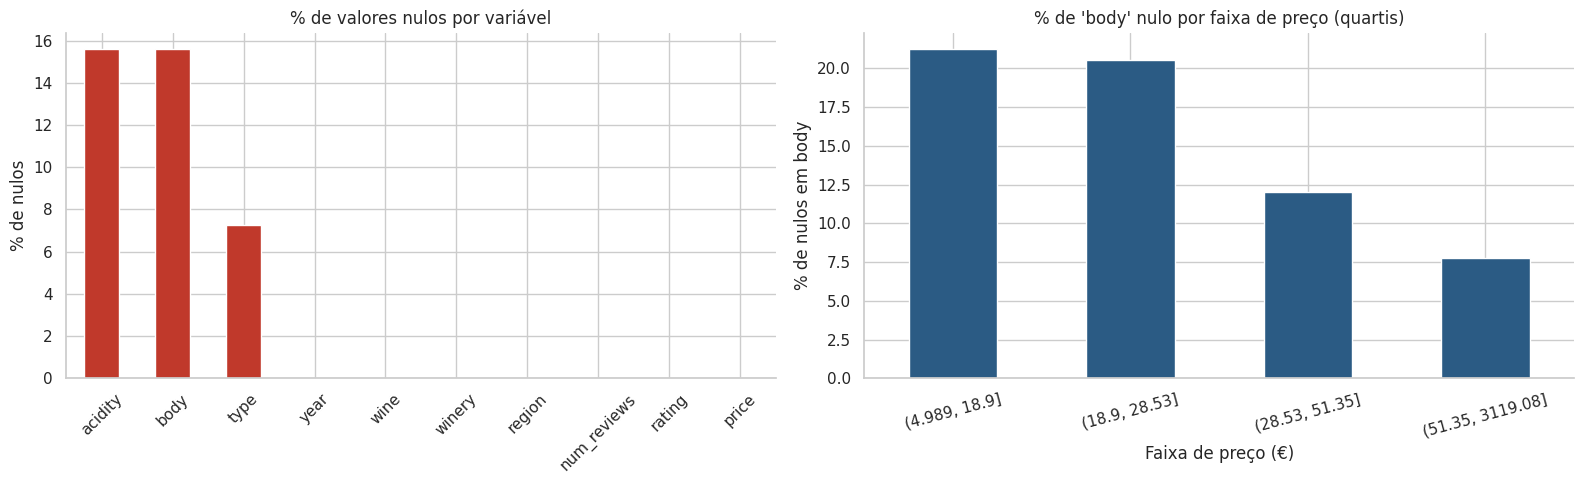

In [102]:
# @title Diagnóstico dos valores nulos

display(Markdown("#### Contagem de nulos por variável"))
print(df.isnull().sum())

nb = df['body'].isna()
na = df['acidity'].isna()
print(f"\nbody e acidity ausentes nos MESMOS registros: {(nb & na).sum()} "
      f"(em apenas um deles: {(nb ^ na).sum()})")
print(f"Desses {nb.sum()} registros, {df.loc[nb, 'type'].isna().sum()} "
      f"também não possuem 'type' (vinhos sem metadados).")
print(f"\nrating médio  ->  com body: {df.loc[~nb, 'rating'].mean():.3f}  |  "
      f"sem body: {df.loc[nb, 'rating'].mean():.3f}")

# Relação da ausência com o preço (quartis)
df['_fx_preco'] = pd.qcut(df['price'], 4)
null_por_preco = (df.groupby('_fx_preco', observed=True)['body']
                    .apply(lambda s: s.isna().mean() * 100))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

(df.drop(columns='_fx_preco').isnull().mean().mul(100)
   .sort_values(ascending=False)
   .plot(kind='bar', ax=axes[0], color='#c0392b'))
axes[0].set(title="% de valores nulos por variável", ylabel="% de nulos", xlabel="")
axes[0].tick_params(axis='x', rotation=45)

null_por_preco.plot(kind='bar', ax=axes[1], color='#2b5b84')
axes[1].set(title="% de 'body' nulo por faixa de preço (quartis)",
            ylabel="% de nulos em body", xlabel="Faixa de preço (€)")
axes[1].tick_params(axis='x', rotation=15)

sns.despine()
plt.tight_layout()
plt.show()

df = df.drop(columns='_fx_preco')

### Leitura do diagnóstico e decisões

**O que os dados mostram:**

1. `body` e `acidity` estão ausentes **exatamente nos mesmos 1.169 registros**.
2. Desses, **545 também não têm `type`**.
3. A taxa de ausência **cai conforme o preço sobe** (~21% no quartil mais barato → ~8% no mais caro). Logo, **não é MCAR** (não aleatório): é um padrão **MAR**, em que a ausência depende do preço.
4. O `rating` quase não muda entre presentes e ausentes, então a nota não explica a ausência.

**Estratégias consideradas e por que foram (ou não) escolhidas:**

| Estratégia | Decisão | Motivo |
|---|---|---|
| Excluir linhas (listwise) | ❌ | Perderia ~15,6% dos dados e enviesaria a amostra para vinhos caros (já que os baratos faltam mais). |
| Preencher com 0 | ❌ | 0 está **fora da escala** (body 2–5, acidity 1–3); cria categoria fantasma e gerou o artefato de correlação 0.92. |
| Média global | ❌ | Ignora a forte dependência de `type`; produz valor não-inteiro, sem sentido numa escala ordinal. |
| **Mediana por `type` + flag de ausência** | ✅ | `body`/`acidity` são essencialmente uma **propriedade do tipo de vinho**; a mediana respeita a escala ordinal e é robusta. A flag preserva o sinal de ausência (que é informativo, por ser MAR). |
| `type` ausente → categoria nova | ❌ | Criaria um rótulo artificial que distorceria as análises por tipo (Q3, Q6). Preferimos **manter `type` nulo** e usar a mediana global como *fallback* só na imputação. |

**Decisão final:** imputar `body` e `acidity` pela **mediana do respectivo `type`** (com *fallback* na mediana global para os 545 sem tipo), criar as flags `body_informado` / `acidity_informado`, e converter os 2 nulos de `year` para `'N.V.'` (sem safra definida).

In [103]:
# @title Aplicação do tratamento de nulos

# 1) Flags de ausência — a ausência é informativa (padrão MAR, ligado ao preço).
#    Preservar esse sinal permite responder Q7/Q8 só com valores medidos de fato.
df['body_informado'] = df['body'].notna().astype(int)
df['acidity_informado'] = df['acidity'].notna().astype(int)

# 2) Imputação ordinal: mediana do próprio 'type' (body/acidity são
#    essencialmente uma propriedade do tipo de vinho). Fallback = mediana
#    global para os 545 registros que também não têm 'type'.
for col in ['body', 'acidity']:
    df[col] = df.groupby('type')[col].transform(lambda s: s.fillna(s.median()))
    df[col] = df[col].fillna(df[col].median()).astype(int)

# 3) year: os 2 nulos passam a 'N.V.' (tratados como não-vintage, sem safra).
df['year'] = df['year'].fillna('N.V.')

display(Markdown("#### Verificação após o tratamento"))
print("Nulos restantes:")
print(df[['body', 'acidity', 'year']].isnull().sum())
print(f"\n'type': {df['type'].isnull().sum()} nulos mantidos propositalmente "
      f"(decisão justificada acima).")

display(Markdown("Distribuição final de **body** e **acidity**:"))
display(pd.concat([
    df['body'].value_counts().sort_index().rename('body'),
    df['acidity'].value_counts().sort_index().rename('acidity')
], axis=1))

#### Verificação após o tratamento

Nulos restantes:
body       0
acidity    0
year       0
dtype: int64

'type': 545 nulos mantidos propositalmente (decisão justificada acima).


Distribuição final de **body** e **acidity**:

,body,acidity
2,38.0,291.0
3,610.0,7174.0
4,5061.0,NaN
5,1791.0,NaN
1,NaN,35.0


### Validação e decisões de uso

**Resultado:** `body` e `acidity` ficam sem nenhum nulo. A distribuição reforça os níveis medianos dominantes (corpo 4, acidez 3), efeito natural da imputação por mediana — aceitável porque esses já eram os valores mais frequentes e a alternativa (descartar 15% das linhas, enviesando para vinhos caros) seria pior.

**Validação metodológica (por que a mediana por `type` é defensável):** comparando a matriz de correlação antes/depois:

| Par | Preenchimento com 0  | Imputação por `type` | Observado (dados reais) |
|---|---|---|---|
| `body` ↔ `acidity` | **0.92** (crítico) | **−0.02** | −0.018 |
| `body` ↔ `rating` | 0.138 | 0.161 | 0.163 |
| `body` ↔ `price` | 0.133 | 0.155 | 0.154 |

A imputação por grupo **eliminou a correlação espúria** de 0.92 e devolveu coeficientes praticamente idênticos aos observados nos dados reais — ou seja, preencheu os nulos **sem inventar relações** que não existem.

**Como isso afeta o restante do notebook:**
- As análises gerais (univariada, correlação, contingência) usam a base completa imputada.
- As perguntas que exigem medição real — **Q7** (corpo) e **Q8** (acidez) — usam as flags `body_informado` / `acidity_informado` para considerar apenas os valores originalmente medidos, garantindo conclusões não enviesadas pela imputação.

---


## Tratamento de Tipos e Formatação

Com os nulos já resolvidos na etapa anterior, padroniza-se `price` (float com 2 casas decimais) e garante-se o tipo inteiro de `body`/`acidity`.

In [104]:
# @title Tratamento de tipos e formatação
df['price'] = df['price'].astype(float)   # Convertendo para float
df['price'] = df['price'].round(2)        # Padronizando com duas casas decimais

# Os nulos de body/acidity já foram tratados na etapa "Tratamento de Valores Nulos";
# aqui apenas garantimos o tipo inteiro.
df['body'] = df['body'].astype(int)
df['acidity'] = df['acidity'].astype(int)

## Perguntas e Hipóteses

> Cada pergunta recebeu um código (**Q1–Q8**) que é citado nos títulos dos gráficos e nas conclusões, para deixar explícito onde ela é respondida.

**Q1. Há uma relação entre a avaliação e o preço do vinho?**

Hipótese: Quanto maior for a avaliação do vinho, maior será o seu valor de mercado.

**Q2. A região do vinho afeta sua avaliação?**

Hipótese: Vinhos produzidos em regiões renomadas possuem, em média, uma qualidade superior em comparação com vinhos de regiões menos conhecidas.

**Q3. O tipo de vinho interfere no valor?**

Hipótese: Existem tipos de vinhos mais caros, por conta de sua região, condição de produção, idade, marca e variedade da uva.

**Q4. Qual a relação entre avaliação, preço e ano?**

Hipótese: Vinhos com notas altas e de anos mais antigos possuem preços mais elevados.

**Q5. Existe uma relação entre o preço e a quantidade de reviews?**

Hipótese: Por ser mais acessível ao público, existe uma maior quantidade de reviews de vinhos mais baratos do que de vinhos mais caros.

**Q6. Como a diversidade de tipos de vinho varia entre as 10 principais regiões produtoras de vinho?**

Hipótese: Entre as 10 principais regiões produtoras de vinho, algumas regiões apresentam uma maior diversidade de tipos de vinho devido a fatores como clima, solo e tradição vitivinícola.

**Q7. Como o corpo do vinho influencia o preço dos vinhos com avaliação acima de 4.0 em diferentes regiões da Espanha?**

Hipótese: Vinhos com corpo mais intenso e avaliação acima de 4.0 são geralmente mais caros, refletindo a percepção de qualidade e a exclusividade.

**Q8. A acidez do vinho interfere em seu preço?**

Hipótese: Vinhos com acidez moderada possuem preços mais altos, pois são considerados mais equilibrados e agradáveis ao paladar.

---

### Onde cada pergunta é respondida

| Pergunta | Categoria de análise | Célula(s) |
|---|---|---|
| **Q1** – avaliação × preço | Bivariada / Multivariada | *Comportamento par a par*, *Matriz de Correlação*, *Mapa de Calor e Dispersão* |
| **Q2** – região × avaliação | Bivariada | *Q2 — Região × Avaliação* (+ reforço na Multivariada) |
| **Q3** – tipo × preço | Bivariada | *Q3 — Tipo × Preço* |
| **Q4** – avaliação, preço e ano | Multivariada | *Distribuição Conjunta (era × região)* |
| **Q5** – preço × nº de reviews | Bivariada | *Comportamento par a par*, *Matriz de Correlação* |
| **Q6** – diversidade de tipos por região | Bivariada (qual × qual) | *Q6 — Diversidade de tipos por região* |
| **Q7** – corpo × preço × região (rating > 4.0) | Multivariada | *Q7 — Corpo × Preço × Região* |
| **Q8** – acidez × preço | Bivariada | *Q8 — Acidez × Preço* |


## Análise Univariada

In [105]:
# @title Resumo Estatístico

display(Markdown("#### Variáveis Qualitativas"))
display(df.describe(include='str'))

display(Markdown("#### Variáveis Quantitativas"))
display(df.describe())

#### Variáveis Qualitativas

,winery,wine,year,region,type
count,7500,7500,7500,7500,6955
unique,480,847,71,76,21
top,Contino,Reserva,2011,Rioja,Rioja Red
freq,457,467,1190,2440,2357


#### Variáveis Quantitativas

,rating,num_reviews,price,body,acidity,body_informado,acidity_informado
count,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000,7500.000000
mean,4.254933,451.109067,60.095823,4.147333,2.951867,0.844133,0.844133
std,0.118029,723.001856,150.356676,0.564567,0.234856,0.362753,0.362753
min,4.200000,25.000000,4.990000,2.000000,1.000000,0.000000,0.000000
25%,4.200000,389.000000,18.900000,4.000000,3.000000,1.000000,1.000000
50%,4.200000,404.000000,28.530000,4.000000,3.000000,1.000000,1.000000
75%,4.200000,415.000000,51.350000,4.000000,3.000000,1.000000,1.000000
max,4.900000,32624.000000,3119.080000,5.000000,3.000000,1.000000,1.000000


### Distribuição de Variáveis

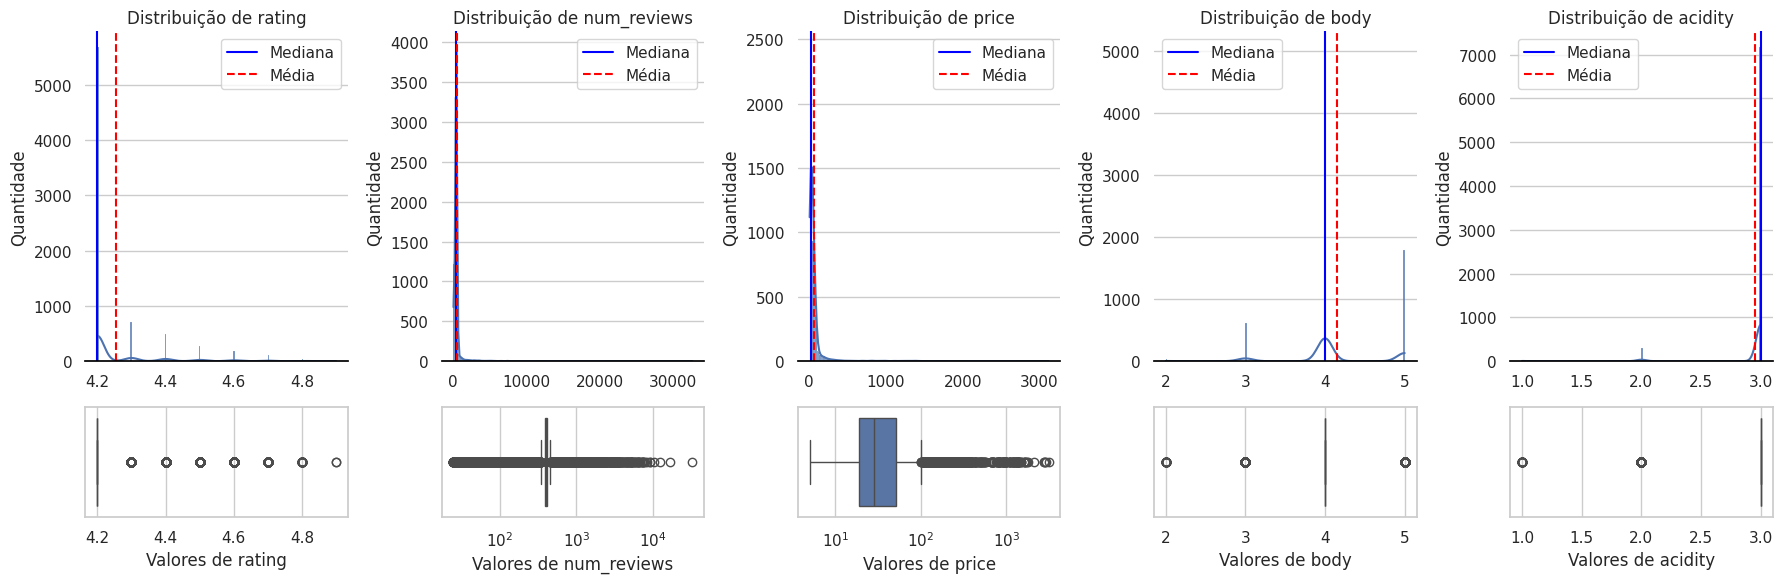

In [106]:
# @title Variáveis Quantitativas  (univariada — base p/ Q1, Q5, Q7, Q8)

variaveis_quantitativas = df_dict.query("tipo == 'quantitativa'").variavel.to_list()

fig, axes = plt.subplots(figsize=(18, 6), ncols=len(variaveis_quantitativas), nrows=2,
                         gridspec_kw={"height_ratios": [3, 1]})

for i, variavel in enumerate(variaveis_quantitativas):

    use_log = True if variavel in ['price', 'num_reviews'] else False


    ax = sns.histplot(data=df, x=variavel, ax=axes[0, i], kde=True, alpha=.8)


    mediana = df[variavel].median()
    media = df[variavel].mean()

    ax.axvline(mediana, color="blue", label="Mediana")
    ax.axvline(media, color="red", linestyle="--", label="Média")

    ax.set(title=f"Distribuição de {variavel}", ylabel="Quantidade", xlabel="")
    ax.legend()


    ax.spines["bottom"].set_color("black")
    ax.grid(False, axis="x")
    for side in ["left", "top", "right"]:
        ax.spines[side].set_visible(False)


    ax_box = sns.boxplot(data=df, x=variavel, ax=axes[1, i])
    if use_log:
        ax_box.set_xscale('log')
    ax_box.set(xlabel=f"Valores de {variavel}")

plt.tight_layout()
plt.show()

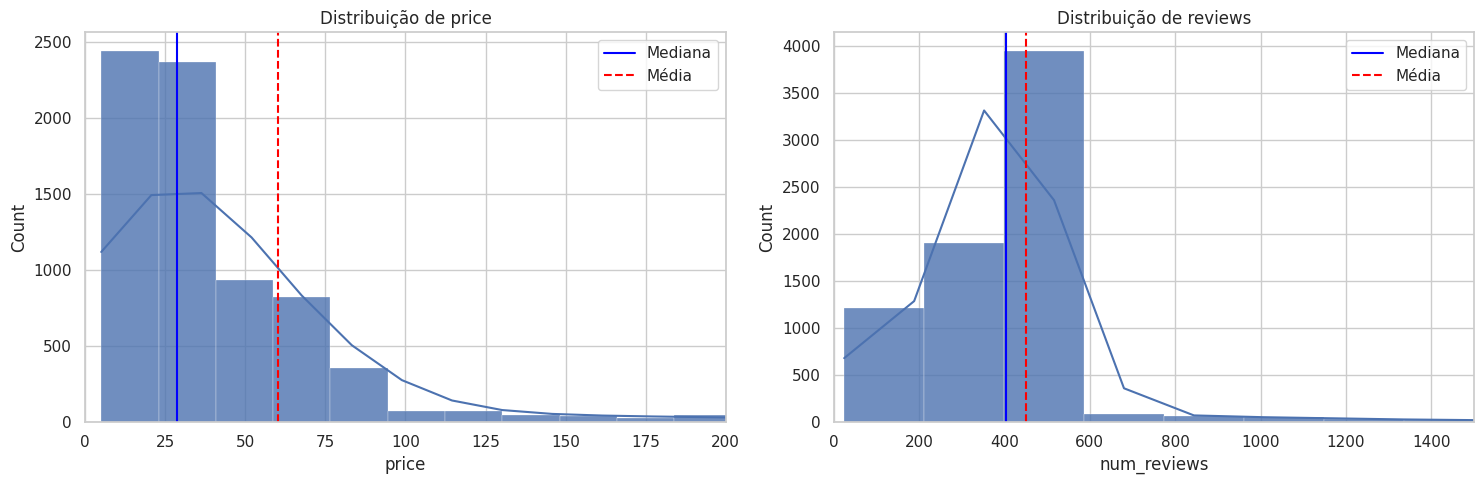

In [129]:
#Melhoria na visualização dos gráficos de preço e número de avaliações.
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(data=df, x="price", kde=True, alpha=0.8, ax=axes[0])

mediana_price = df["price"].median()
media_price = df["price"].mean()

axes[0].axvline(mediana_price, color="blue", label="Mediana")
axes[0].axvline(media_price, color="red", linestyle="--", label="Média")
axes[0].set(title="Distribuição de price", xlim=(0, 200))
axes[0].legend()

sns.histplot(data=df, x="num_reviews", kde=True, alpha=0.8, ax=axes[1])

mediana_reviews = df["num_reviews"].median()
media_reviews = df["num_reviews"].mean()

axes[1].axvline(mediana_reviews, color="blue", label="Mediana")
axes[1].axvline(media_reviews, color="red", linestyle="--", label="Média")
axes[1].set(title="Distribuição de reviews", xlim=(0, 1500))
axes[1].legend()

plt.tight_layout()

plt.show()

---

> *Análise descritiva (univariada) — serve de base de leitura para as perguntas relacionais **Q1, Q5, Q7 e Q8**.*

**Distribuição da variável rating**

- A maior parte dos vinhos está concentrada na nota 4.2, que coincide com a mediana e também é o valor mais frequente do conjunto (5.679 de 7.500 registros).

- As notas acima de 4.2 aparecem de forma mais isolada (a nota 4.9 tem apenas 2 vinhos), o que indica que avaliações muito altas existem, mas são exceções dentro do dataset.

**Distribuição da variável num_reviews**

- Ao contrário do que a forma do histograma sugere, os vinhos **não** se concentram próximo de zero: o mínimo é 25 avaliações e o intervalo interquartil é bastante estreito (entre 389 e 415), com mediana de 404.

- O histograma parece "achatado" à esquerda apenas porque alguns poucos vinhos possuem um volume extremamente alto de avaliações (mais de 32.000), atuando como outliers que esticam a escala. O boxplot em escala logarítmica torna essa concentração em torno de ~400 muito mais visível.

**Distribuição da variável price**

- A maioria dos preços está concentrada em valores baixos (75% dos vinhos custam até ~51€ e a mediana é 28,53€).

- Fica evidente uma diferença considerável entre média (60,10€) e mediana (28,53€), sugerindo que vinhos muito caros (até 3.119€) puxam a média para cima e distorcem a percepção do preço "típico".

**Distribuição das variáveis body e acidity**

- Não há mais barra em "0": os 1.169 valores ausentes foram imputados na etapa *Tratamento de Valores Nulos* pela mediana do respectivo `type`, preservando a escala ordinal.

- A maior parte dos vinhos tem **corpo nível 4** (5.061 registros), seguido pelo nível 5 (1.791); os corpos mais leves 3 e 2 são raros (610 e 38). A média fica em ~4,15 — antes era artificialmente puxada para ~3,51 pelo antigo preenchimento com 0.

- A **acidez** concentra-se fortemente no **nível 3** (7.174 registros); os níveis 2 e 1 são raros (291 e 35). Como a imputação usa a mediana por `type`, ela reforça os níveis medianos dominantes (4 em body, 3 em acidity) — efeito esperado e justificado na etapa de tratamento.

---


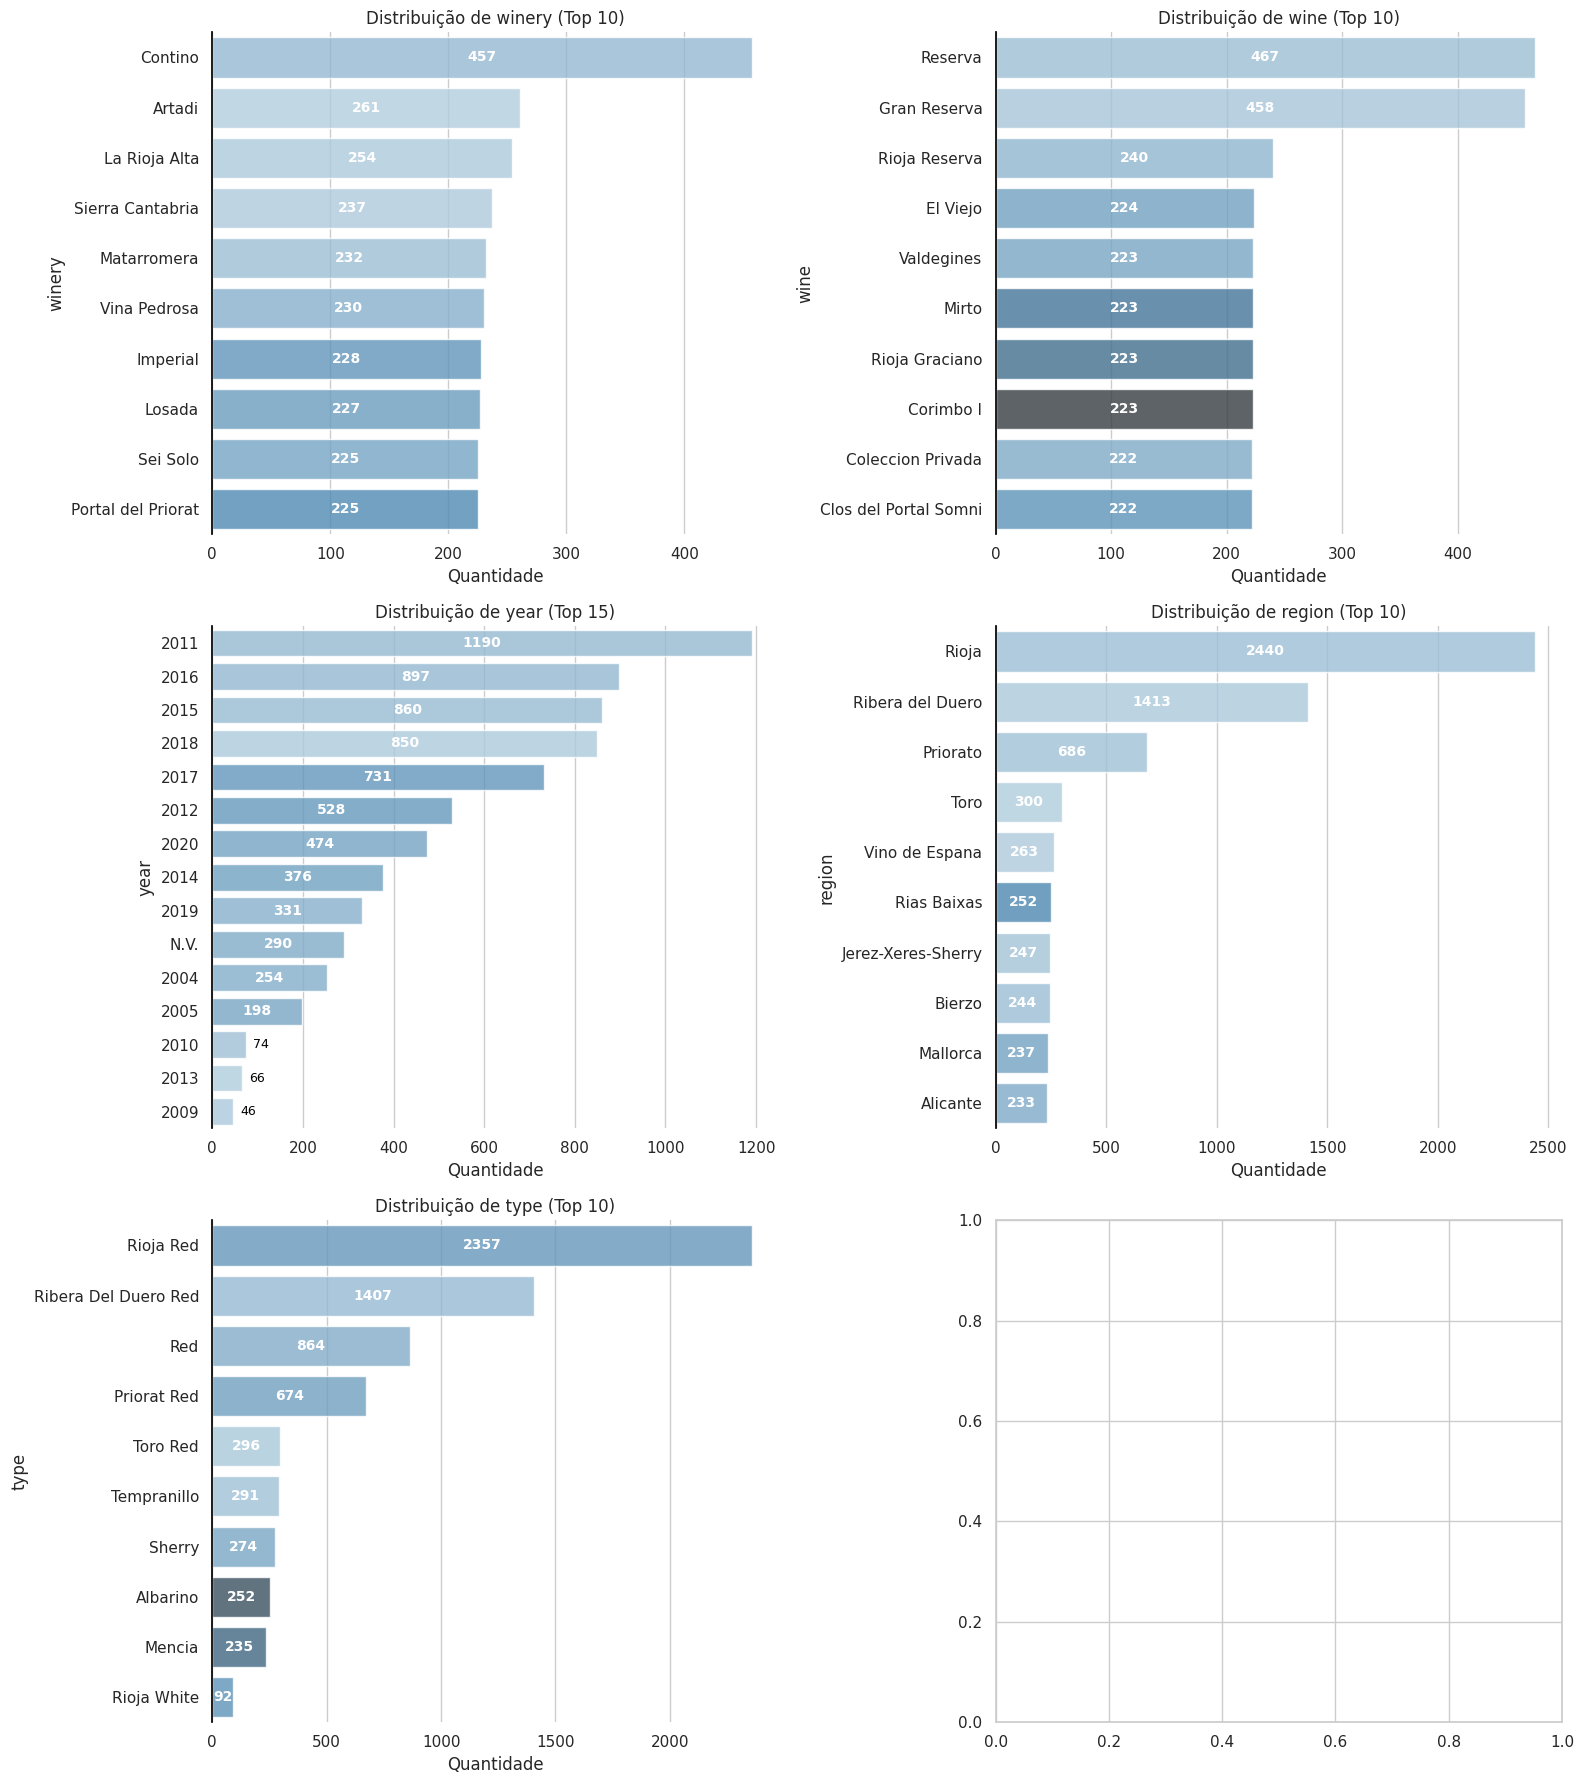

In [107]:
# @title Variáveis Qualitativas  (univariada — base p/ Q3, Q6)

variaveis_qualitativas = df_dict.query("tipo == 'qualitativa'").variavel.to_list()

fig, axes = plt.subplots(figsize=(16, 18), ncols=2, nrows=3)
axes = axes.flatten()

for i, variavel in enumerate(variaveis_qualitativas):
    top_n = 15 if variavel == "year" else 10
    order = df[variavel].value_counts().index[:top_n]

    ax = sns.countplot(data=df, y=variavel, ax=axes[i], order=order, palette="Blues_d", hue=variavel, legend=False, alpha=.8)

    for bar in ax.patches:
        width = bar.get_width()

        if width > 80:
            ax.text(width/2, bar.get_y() + bar.get_height()/2,
                   f'{int(width)}',
                   ha='center', va='center', color='white', fontweight='bold', fontsize=10)
        else:
            ax.text(width + 15, bar.get_y() + bar.get_height()/2,
                   f'{int(width)}',
                   ha='left', va='center', color='black', fontsize=9)

    ax.set(title=f"Distribuição de {variavel} (Top {top_n})", xlabel="Quantidade")

    for side in ["bottom", "top", "right"]:
        ax.spines[side].set_visible(False)
    ax.spines["left"].set_color("black")

plt.tight_layout()
plt.show()

---

**Winery (Vinícola)**
 - A vinícola Contino é a que possui a maior quantidade de rótulos no dataset, destacando-se das demais que mantêm uma distribuição mais equilibrada entre 200 e 300 unidades.

**Wine (Vinho)**
-  Os nomes de vinhos mais frequentes são Reserva (467) e Gran Reserva (458).

**Year (Ano)**
- O ano de 2011 é a safra com maior presença absoluta, com quase 1.200 registros. É interessante notar a presença da categoria "N.V." entre os mais frequentes, representando vinhos sem uma safra específica definida.

**Region (Região)**
- A região de Rioja é a principal origem dos vinhos, com mais de 2.400 registros, seguida por Ribera del Duero. Juntas, elas dominam grande parte da amostra.

**Type (Tipo)**
- O tipo Rioja Red é o mais comum, o que é coerente com a dominância da região de Rioja observada anteriormente.

---

## Análise Bivariada

### Relação entre variáveis quantitativas

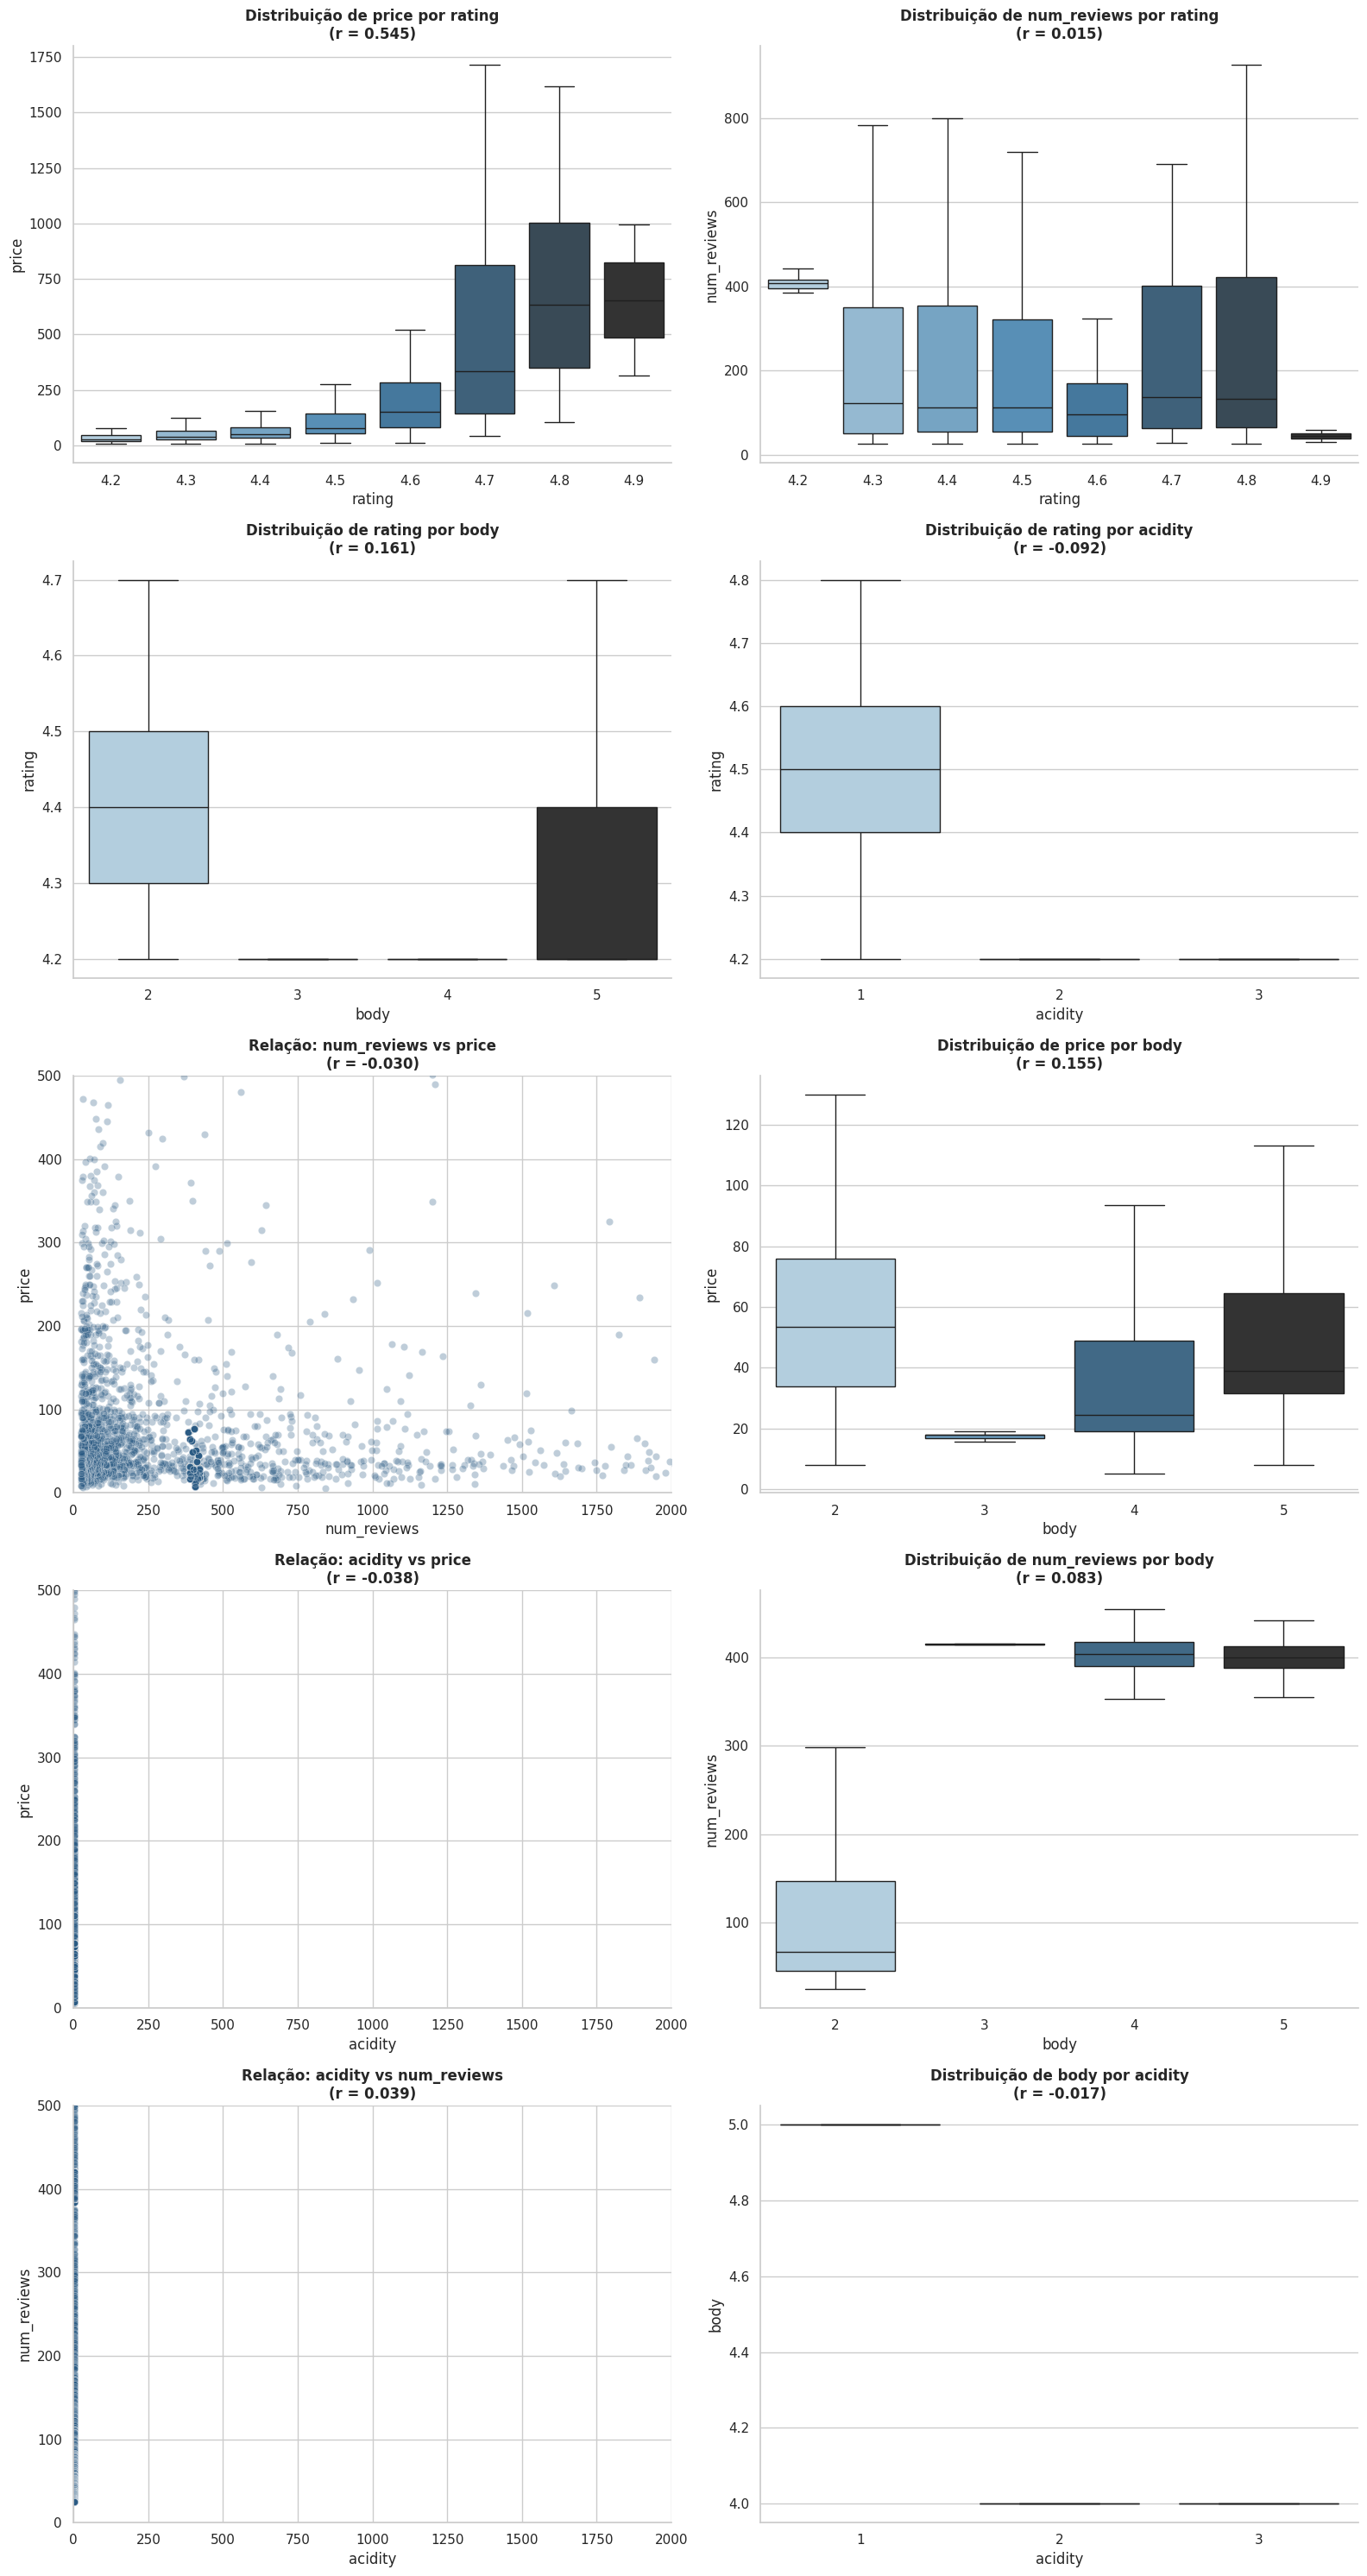

In [108]:
# @title Comportamento par a par — Responde Q1 (avaliação × preço) e Q5 (preço × nº de reviews)

vars_quant = ['rating', 'price', 'num_reviews', 'body', 'acidity']
combinacoes = list(itertools.combinations(vars_quant, 2))

fig, axes = plt.subplots(figsize=(16, 30), ncols=2, nrows=5)
axes = axes.flatten()

for i, (v1, v2) in enumerate(combinacoes):

    corr = df[[v1, v2]].corr().iloc[0, 1]


    if 'body' in [v1, v2] or 'rating' in [v1, v2]:
        x_var, y_var = (v1, v2) if df[v1].nunique() < df[v2].nunique() else (v2, v1)
        sns.boxplot(data=df, x=x_var, y=y_var, ax=axes[i],
                   palette="Blues_d", hue=x_var, legend=False, showfliers=False)
        axes[i].set_title(f"Distribuição de {y_var} por {x_var}\n(r = {corr:.3f})",
                         fontsize=12, fontweight='bold')


    else:
        sns.scatterplot(data=df, x=v2, y=v1, ax=axes[i], alpha=0.3, color='#2b5b84')
        axes[i].set_xlim(0, 2000)
        axes[i].set_ylim(0, 500)
        axes[i].set_title(f"Relação: {v2} vs {v1}\n(r = {corr:.3f})",
                         fontsize=12, fontweight='bold')

    sns.despine(ax=axes[i])

plt.tight_layout()
plt.show()

---

> **Perguntas respondidas aqui:** **Q1** (avaliação × preço) e **Q5** (preço × nº de reviews). Também é a base para **Q7** (corpo × preço) e **Q8** (acidez × preço), aprofundadas em células dedicadas.

### Análise do Comportamento Par a Par

Nesta etapa, foram analisadas as relações entre as principais variáveis do dataset. Para evitar que valores extremos prejudicassem a visualização, os eixos de price e num_reviews foram limitados e os outliers foram ocultados nos boxplots. Desse modo, ficou mais fácil enxergar as tendências centrais e os padrões mais representativos dos dados.

> `body` e `acidity` já estão imputados (mediana por `type`, ver *Tratamento de Valores Nulos*). Como validado naquela etapa, a imputação por grupo **preservou a estrutura de correlação real**, então os coeficientes abaixo podem ser lidos normalmente (sem o artefato do antigo preenchimento com 0).

#### Principais Insights

**Preço vs. Rating (r = +0.545) — responde Q1**

- Essa é a relação mais evidente do conjunto. Conforme o rating aumenta, o preço também sobe de forma clara, principalmente a partir da nota 4.6. Vinhos com avaliações mais altas passam a ocupar faixas de preço bem superiores. **A hipótese de Q1 se confirma:** maior avaliação acompanha maior preço.

**Rating vs. Número de Reviews (r = +0.015)**

- A relação é praticamente inexistente. Ter muitas avaliações não significa, necessariamente, ter uma nota mais alta. Popularidade e qualidade percebida não caminham juntas nesse dataset.

**Preço vs. Número de Reviews (r = −0.030) — responde Q5**

- A correlação é praticamente nula e levemente negativa. O preço não influencia o volume de avaliações: há tanto vinhos acessíveis quanto vinhos de alto valor com níveis semelhantes de engajamento. **A hipótese de Q5 (vinhos mais baratos teriam mais reviews) não se sustenta.**

**Body vs. Rating (r = +0.161)**

- Correlação fraca, mas positiva: vinhos mais encorpados tendem a notas um pouco mais altas, e o body nível 5 é o que mais frequentemente atinge as notas máximas (4.8 e 4.9).

**Body vs. Preço (r = +0.155) — base para Q7**

- Existe uma tendência leve, porém consistente, de vinhos mais encorpados apresentarem preços mais altos, especialmente nos níveis 4 e 5. (Aprofundado na análise multivariada de Q7.)

---


### Correlação

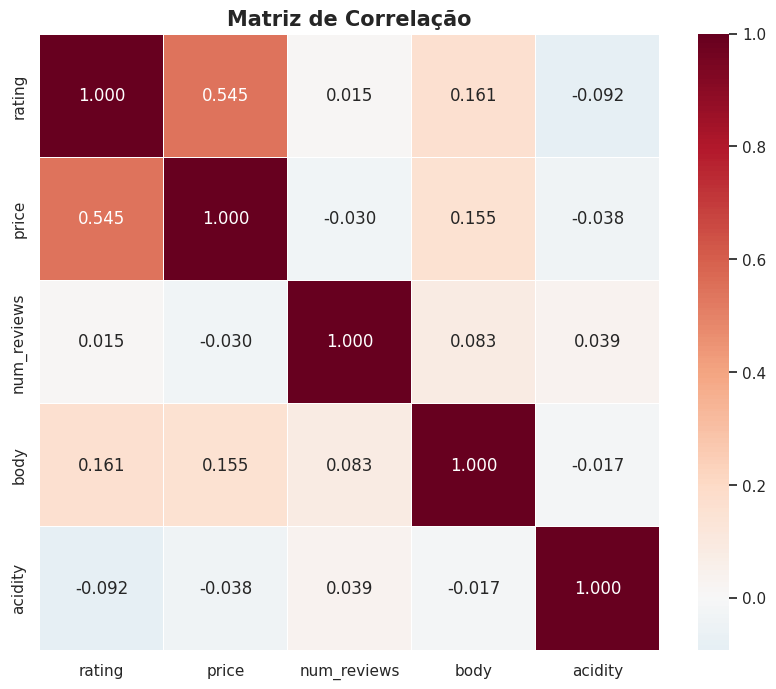

In [109]:
# @title Matriz de Correlação (Heatmap) — Síntese de Q1, Q5 e Q8

cols_quant = ['rating', 'price', 'num_reviews', 'body', 'acidity']
corr_matrix = df[cols_quant].corr()


plt.figure(figsize=(10, 8))


sns.heatmap(corr_matrix,
            annot=True,
            fmt=".3f",
            cmap='RdBu_r',
            center=0,
            linewidths=0.5)

plt.title('Matriz de Correlação', fontsize=15, fontweight='bold')
plt.show()

---
- Ordenando as correlações com qualidade/preço: **Corr(price, rating) ≈ 0.545 > Corr(rating, body) ≈ 0.161 > Corr(price, body) ≈ 0.155**
- `body` ↔ `acidity` ≈ **−0.02**: praticamente nula. A imputação pela mediana do `type` **não** criou correlação espúria — ao contrário do antigo preenchimento com 0, que inflava artificialmente esse par para 0.92.
---



> **Síntese consolidada das perguntas Q1, Q5 e Q8** (visão geral das correlações, já com `body`/`acidity` imputados por `type`).

**Preço e Qualidade (r = 0.545) — Q1**

- É a relação mais clara do dataset. Conforme o rating aumenta, o preço também sobe de forma consistente. A partir das notas 4.7, o salto de valor fica evidente, mostrando que vinhos muito bem avaliados ocupam uma faixa de preço bem mais alta. **Hipótese de Q1 confirmada.**

**Num_reviews vs. Rating (r = 0.015) e Preço vs. Num_reviews (r = −0.030) — Q5**

- Praticamente não há relação. Ter muitas avaliações não significa ter uma nota maior, nem está ligado ao preço. Isso indica que popularidade e qualidade/valor percebido não estão conectados. **A hipótese de Q5 não se confirma.**

**Body vs. Rating (r = 0.161) e Body vs. Preço (r = 0.155)**

- Correlações fracas, porém positivas e coerentes entre si: vinhos mais encorpados tendem a notas e preços ligeiramente mais altos. O body nível 5 aparece com mais frequência entre as notas mais altas.

**Acidez vs. Preço — Q8**

- No heatmap, `acidity` mostra correlação fraca e **negativa** com preço (≈ −0.04) e rating (≈ −0.09), coerente com o achado de Q8 (acidez mais baixa associada a preços maiores). A resposta conclusiva está na célula dedicada *"Q8 — Acidez × Preço"*, que usa apenas os registros com acidez originalmente medida.

> **Validação da imputação:** o par `body` ↔ `acidity` agora aparece ≈ −0.02 no heatmap, praticamente igual ao valor observado nos dados reais (−0.018). Ou seja, a imputação pela mediana do `type` **eliminou o artefato** que o antigo preenchimento com 0 produzia (0.92) e manteve a estrutura real das correlações. O número de reviews continua com correlação muito baixa com todas as demais variáveis; no geral, o que mais influencia o preço neste dataset é o **rating**.
---


### Q8 — Acidez × Preço

*Análise bivariada (quantitativa)* — relação entre o nível de acidez e o `price`, usando **apenas os registros com acidez originalmente medida** (flag `acidity_informado`, criada no *Tratamento de Valores Nulos*), para responder com base em dados reais e não em valores imputados.

,count,median,mean
acidity,,,
1,35,114.50,148.87
2,268,48.96,75.33
3,6028,28.53,64.80


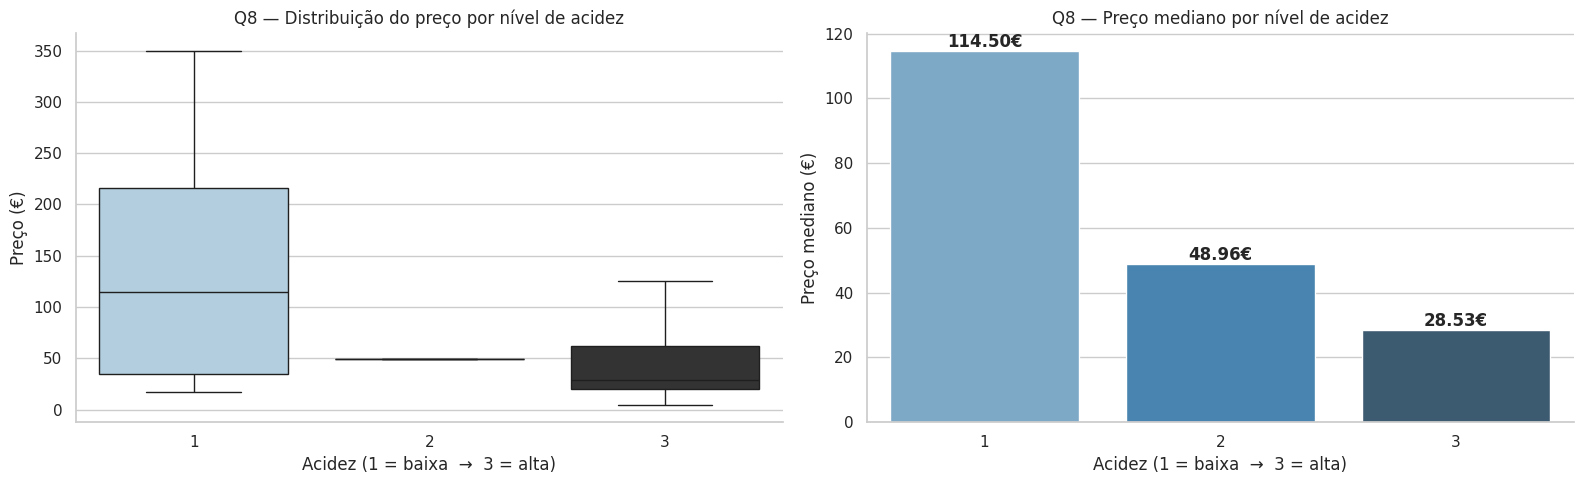

In [110]:
# @title Q8 — Acidez × Preço (responde Q8)

# Usa apenas registros com acidez ORIGINALMENTE medida (flag), não os imputados.
df_q8 = df[df['acidity_informado'] == 1].copy()

resumo_q8 = (df_q8.groupby('acidity')['price']
             .agg(['count', 'median', 'mean']).round(2))
display(resumo_q8)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(data=df_q8, x='acidity', y='price', ax=axes[0],
            palette="Blues_d", hue='acidity', legend=False, showfliers=False)
axes[0].set(title="Q8 — Distribuição do preço por nível de acidez",
            xlabel="Acidez (1 = baixa  →  3 = alta)", ylabel="Preço (€)")

med_ac = df_q8.groupby('acidity')['price'].median()
sns.barplot(x=med_ac.index.astype(str), y=med_ac.values, ax=axes[1],
            palette="Blues_d", hue=med_ac.index.astype(str), legend=False)
for i, v in enumerate(med_ac.values):
    axes[1].text(i, v, f'{v:.2f}€', ha='center', va='bottom', fontweight='bold')
axes[1].set(title="Q8 — Preço mediano por nível de acidez",
            xlabel="Acidez (1 = baixa  →  3 = alta)", ylabel="Preço mediano (€)")

sns.despine()
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q8.** (Cálculo restrito aos 6.331 registros com acidez **originalmente medida** — flag `acidity_informado` —, evitando o viés dos valores imputados.)

| Acidez | Nº de vinhos | Preço mediano | Preço médio |
|---|---|---|---|
| 1 (baixa) | 35 | 114,50€ | 148,87€ |
| 2 (média) | 268 | 48,96€ | 75,33€ |
| 3 (alta) | 6.028 | 28,53€ | 64,80€ |

O comportamento é **inverso** ao previsto: quanto **menor** a acidez, **maior** o preço. Vinhos de acidez baixa (nível 1) têm preço mediano cerca de 4x o dos vinhos de acidez alta (nível 3). Isso é coerente com a correlação fracamente negativa observada no heatmap geral.

**Conclusão:** a hipótese de Q8 (acidez moderada → preços mais altos) **não se confirma**. Ressalvas importantes: a categoria 1 tem pouquíssimos registros (35) e há forte desbalanceamento (≈ 95% dos vinhos têm acidez nível 3), então a tendência, ainda que visível, deve ser interpretada com cautela.

---


### Relação entre variáveis qualitativas

---
#### Tratamento de Variáveis Qualitativas
Para realizar as análises de contingência e de distribuição relativa, alguns ajustes foram necessários no tratamento dos dados.

Como a variável **year** possui muitos valores únicos, a visualização direta em gráficos de barras ficaria pouco legível. Por isso, foi feita uma conversão temporária para o tipo numérico, permitindo o agrupamento em faixas de tempo (eras). Esse agrupamento facilita a identificação de padrões entre safras mais antigas e mais recentes.

Os registros classificados como "N.V." (não-vintage) foram desconsiderados nessa etapa específica, já que não possuem referência cronológica definida e poderiam comprometer a análise temporal.

Além disso, como o dataset contém apenas um país (Espanha — coluna já descartada na exploração inicial), as grades de subplots foram restritas aos principais **tipos de vinho** e às **eras**. Essa redução de categorias ajuda a evitar excesso de informação nos gráficos e mantém o foco nos segmentos com maior representatividade no dataset.

---


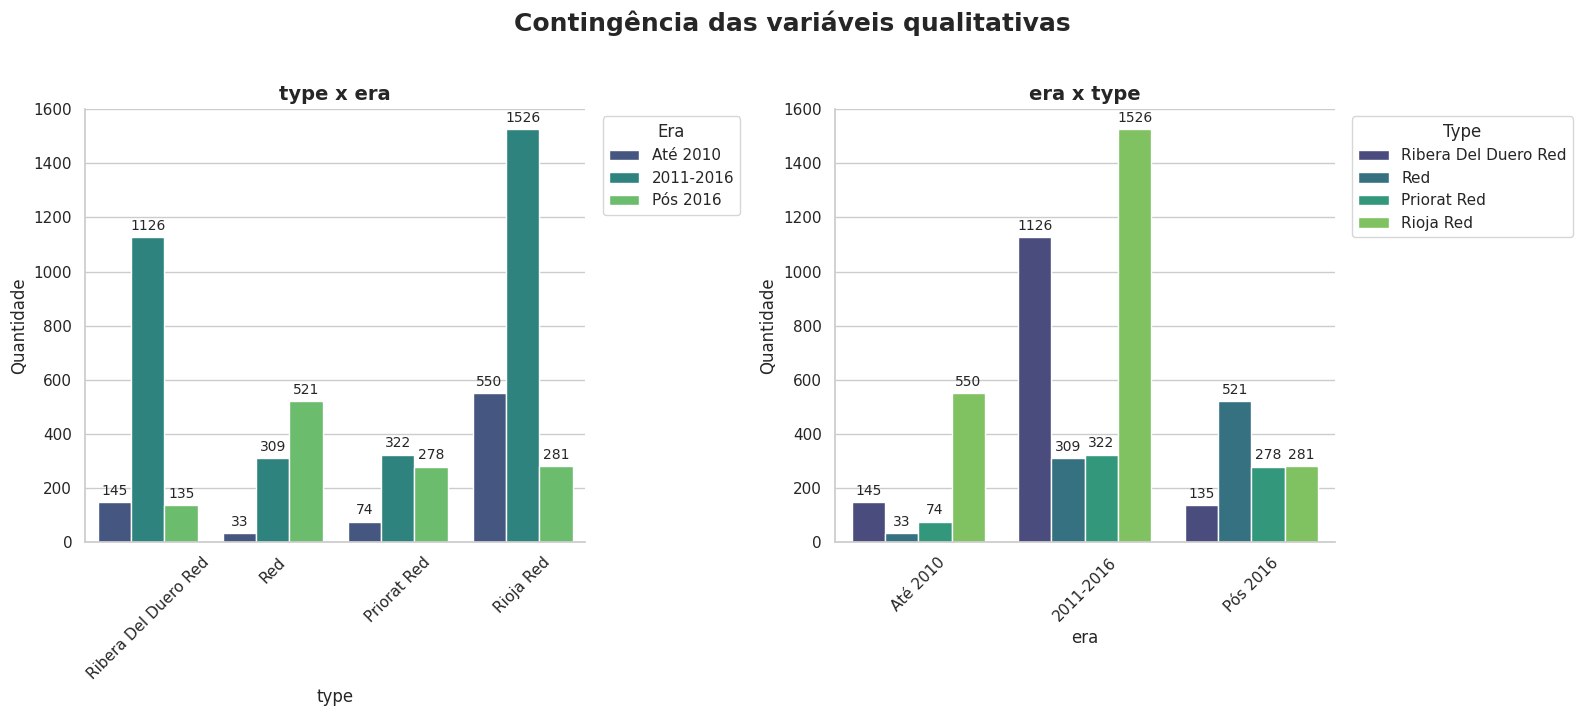

In [111]:
# @title Contingência das variáveis qualitativas — Contexto p/ Q3 e Q6

df_clean = df[df['year'] != 'N.V.'].copy()
df_clean['year'] = pd.to_numeric(df_clean['year'])
top_types = df_clean['type'].value_counts().nlargest(4).index
df_map = df_clean[df_clean['type'].isin(top_types)].copy()
df_map['era'] = pd.cut(df_map['year'], bins=[1900, 2010, 2016, 2022],
                       labels=['Até 2010', '2011-2016', 'Pós 2016'])

vars_qual = ['type', 'era']
combinacoes = list(itertools.permutations(vars_qual, 2))


fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 7))
axes = axes.flatten()

for i, (v1, v2) in enumerate(combinacoes):
    plot = sns.countplot(data=df_map, x=v1, hue=v2, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{v1} x {v2}', fontsize=14, fontweight='bold')
    axes[i].set_ylabel('Quantidade')


    for container in axes[i].containers:
        axes[i].bar_label(container, padding=3, fontsize=10)

    axes[i].legend(title=v2.capitalize(), bbox_to_anchor=(1.02, 1), loc='upper left')
    axes[i].tick_params(axis='x', rotation=45)
    sns.despine(ax=axes[i])

plt.suptitle('Contingência das variáveis qualitativas', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()


---

> ℹ️ Esta contingência dá **contexto** para **Q3** (tipo × valor) e **Q6** (diversidade de tipos por região), respondidas de forma dedicada logo adiante.

- O catálogo é concentrado em vinhos da Espanha, com destaque para o tipo **Rioja Red**, o mais representativo, somando 2.357 unidades. Em seguida, **Ribera Del Duero Red** ocupa a segunda posição, com 1.407 registros.

- O maior volume de rótulos está concentrado no período de 2011 a 2016, que reúne 3.283 registros. Já as safras mais antigas (até 2010) representam a menor parcela do conjunto, com 802 unidades.

- Enquanto categorias específicas como **Rioja**, **Ribera** e **Priorat** apresentam queda nas safras mais recentes, o tipo genérico **"Red"** segue o movimento oposto. O volume cresce de 309 unidades (2011–2016) para 521 no período pós-2016, indicando uma expansão desse segmento nos anos mais novos.

- Há uma redução significativa no volume de **Rioja Red** nas safras mais recentes, passando de 1.526 (2011–2016) para 281 (pós-2016).

---


### Q6 — Diversidade de tipos de vinho por região (Top 10)

*Análise bivariada (qualitativa × qualitativa)* — número de tipos de vinho distintos em cada uma das 10 regiões com mais registros.

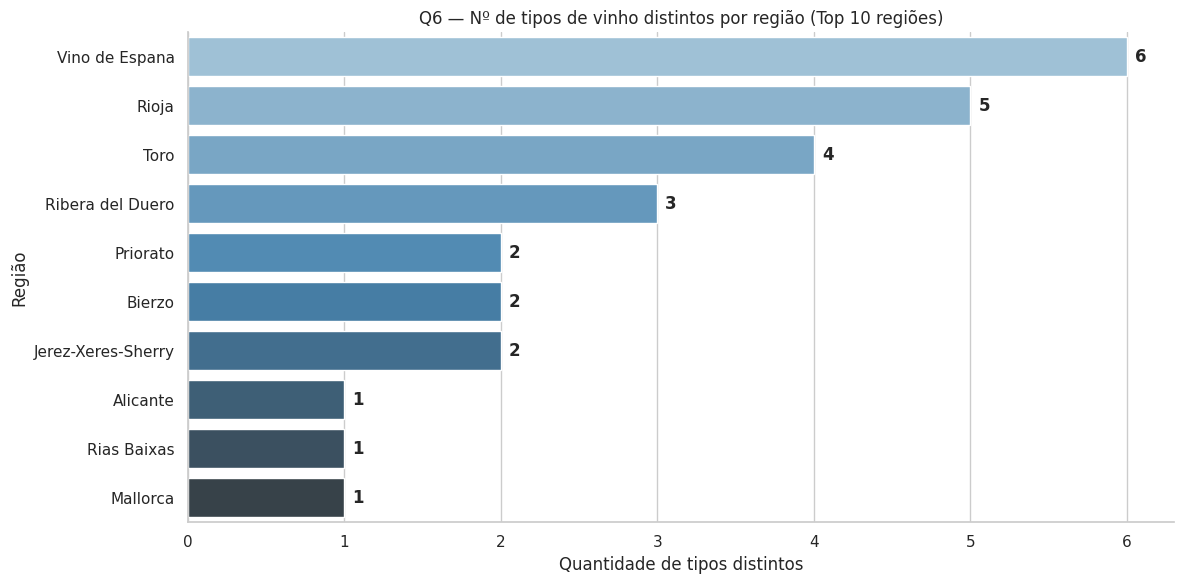

In [112]:
# @title Q6 — Diversidade de tipos por região (responde Q6)

top10_regioes = df['region'].value_counts().nlargest(10).index
diversidade = (df[df['region'].isin(top10_regioes)]
               .groupby('region')['type'].nunique()
               .sort_values(ascending=False))

plt.figure(figsize=(12, 6))
ax = sns.barplot(x=diversidade.values, y=diversidade.index,
                 palette="Blues_d", hue=diversidade.index, legend=False)
for i, v in enumerate(diversidade.values):
    ax.text(v + 0.05, i, str(int(v)), va='center', fontweight='bold')

ax.set(title="Q6 — Nº de tipos de vinho distintos por região (Top 10 regiões)",
       xlabel="Quantidade de tipos distintos", ylabel="Região")
sns.despine()
plt.tight_layout()
plt.show()

---

> ✅ **Resposta da Pergunta Q6.**

A diversidade de tipos varia **bastante** entre as 10 principais regiões:

- **Vino de Espana** (rótulo genérico, sem denominação de origem específica) apresenta a maior variedade (6 tipos), seguido por **Rioja** (5) e **Toro** (4).
- Regiões com denominação de origem forte tendem a ser mais especializadas: **Ribera del Duero** (3), **Priorato**, **Bierzo** e **Jerez-Xeres-Sherry** (2), e **Alicante**, **Rias Baixas** e **Mallorca** com apenas 1 tipo.

**Conclusão:** a hipótese de Q6 **se confirma** — há clara variação na diversidade entre regiões. Curiosamente, a maior diversidade aparece no agrupamento genérico ("Vino de Espana"), enquanto regiões tradicionais e fortemente reguladas concentram a produção em poucos tipos característicos.

---


### Relação entre variáveis quantitativas e qualitativas

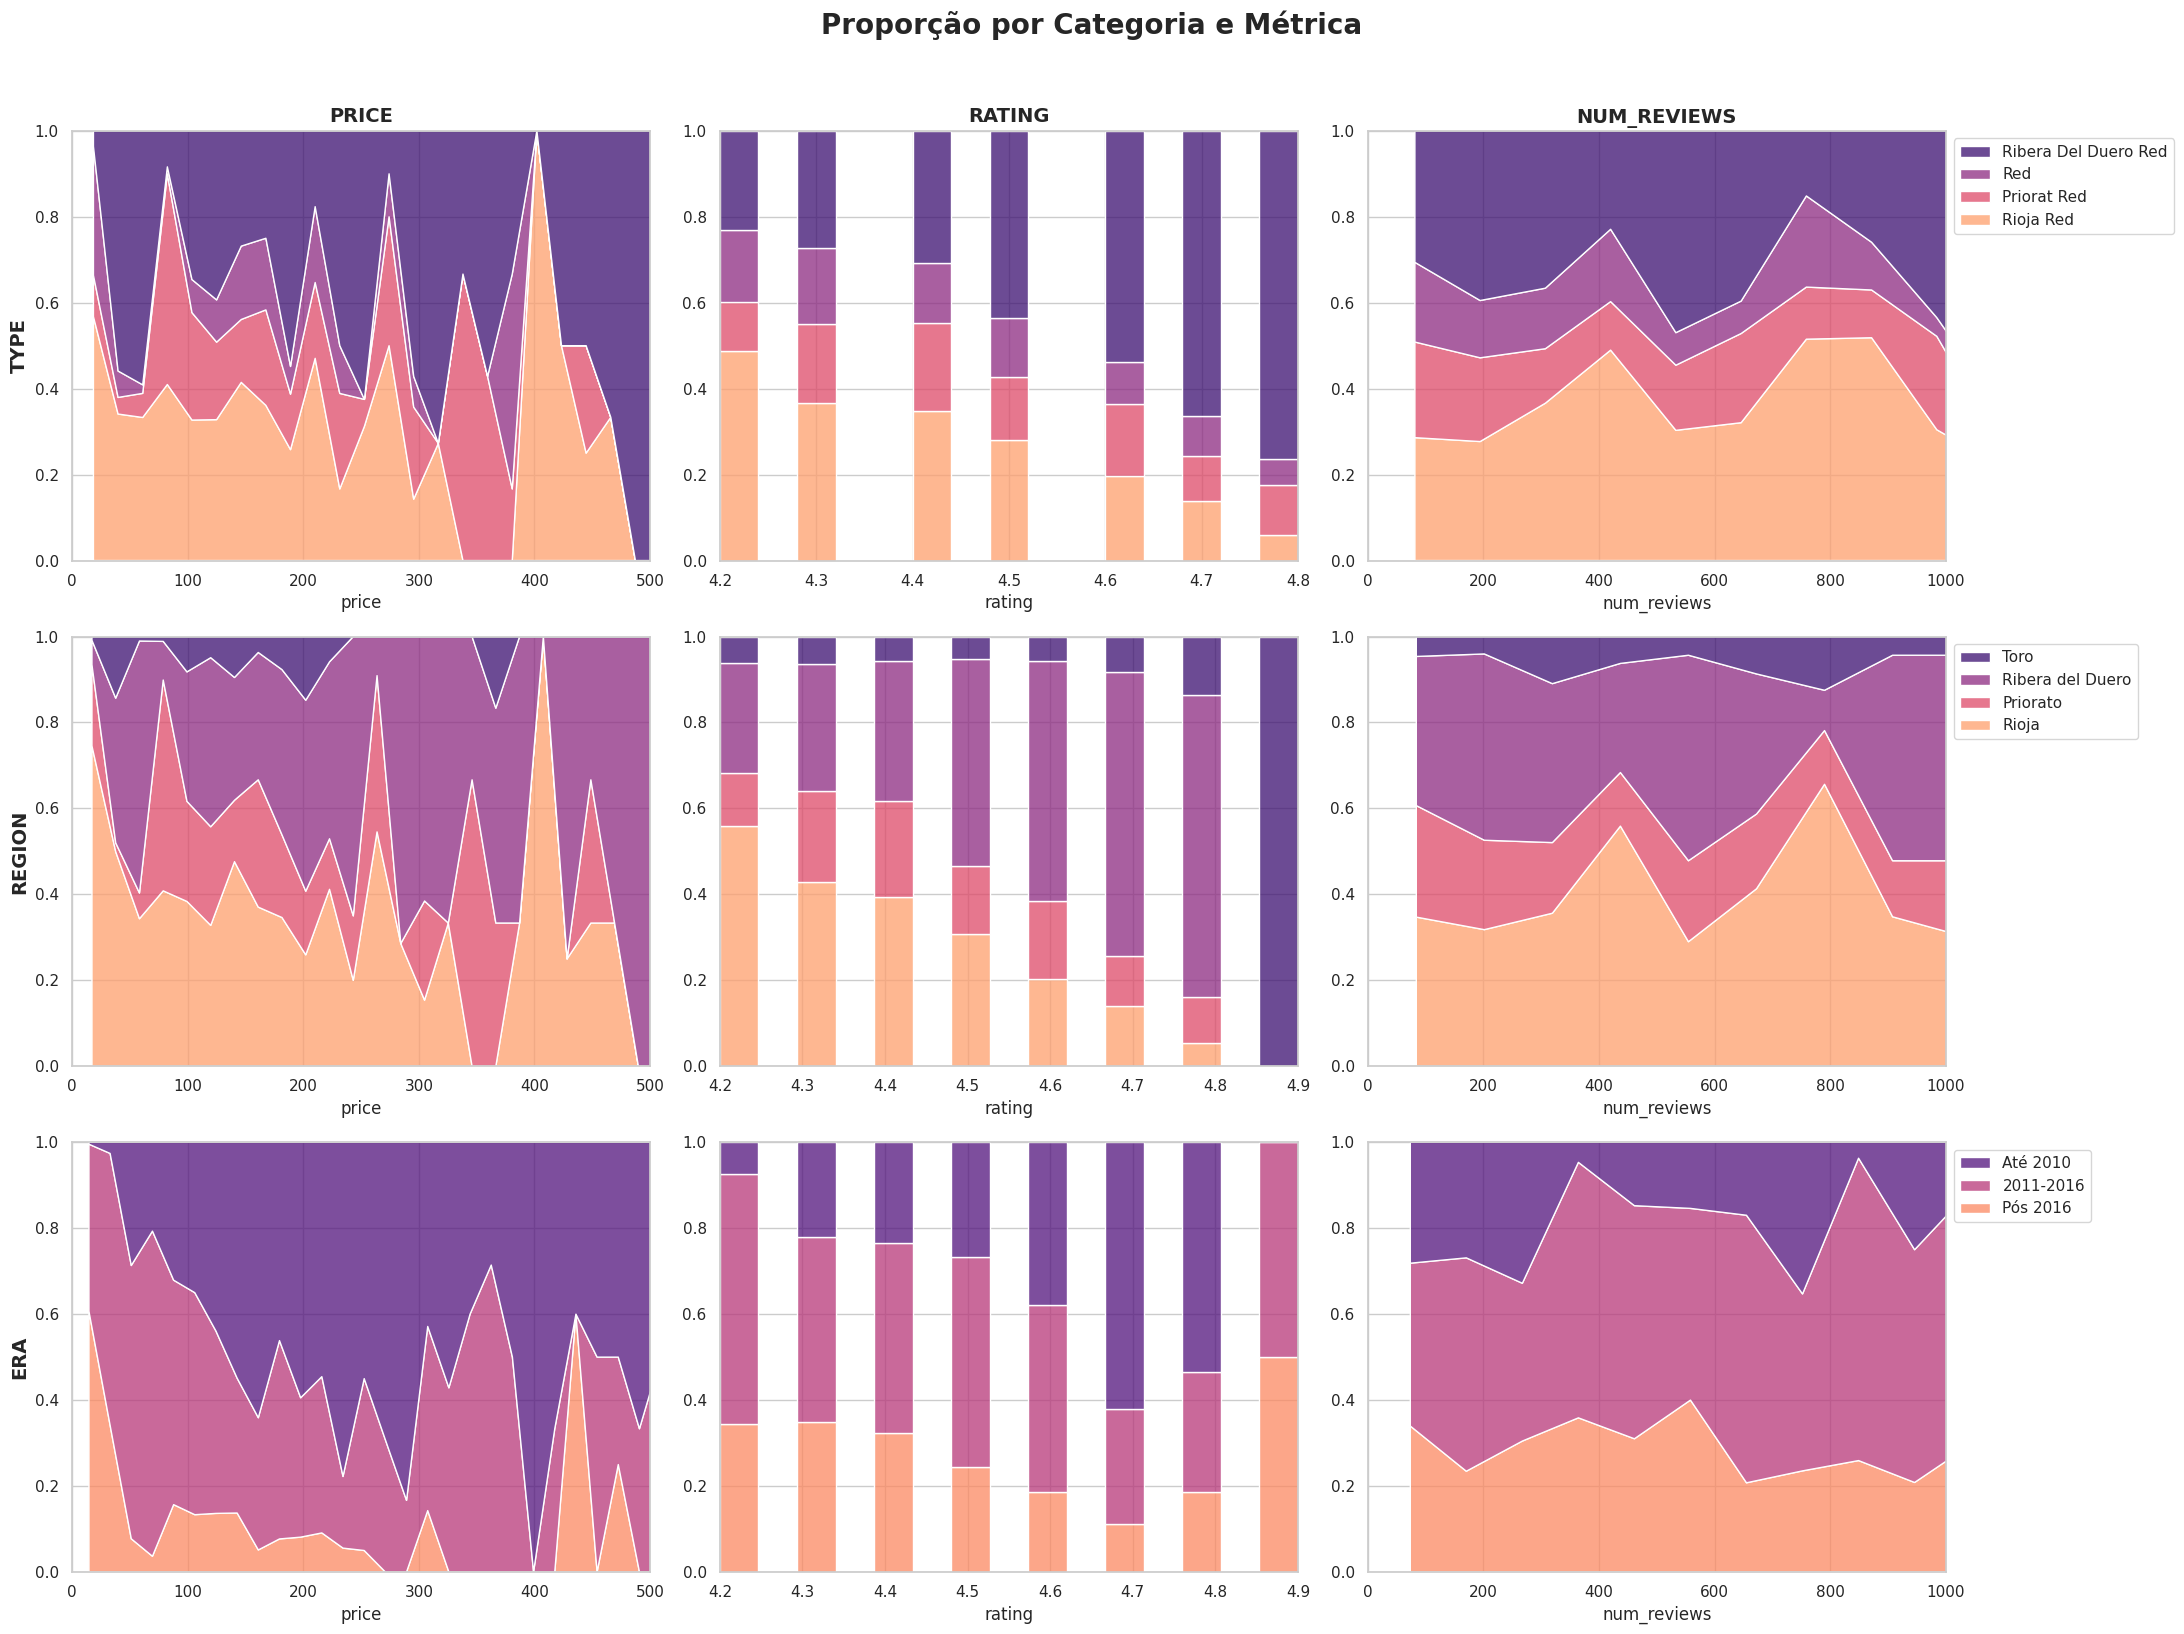

In [113]:
# @title Proporção por Categoria e Métrica — Contexto p/ Q2 (região × rating) e Q3 (tipo × preço)

if 'era' not in df_clean.columns:
    df_clean['era'] = pd.cut(df_clean['year'], bins=[1900, 2010, 2016, 2022],
                             labels=['Até 2010', '2011-2016', 'Pós 2016'])

qual_vars_impacto = ['type', 'region', 'era']
quant_vars_impacto = ['price', 'rating', 'num_reviews']

fig, axes = plt.subplots(nrows=len(qual_vars_impacto), ncols=len(quant_vars_impacto), figsize=(22, 16))

for row, qual in enumerate(qual_vars_impacto):

    top_items = df_clean[qual].value_counts().nlargest(4).index
    df_temp = df_clean[df_clean[qual].isin(top_items)].copy()

    for col, quant in enumerate(quant_vars_impacto):

        if quant == 'rating':
            sns.histplot(data=df_temp, x=quant, hue=qual, multiple='fill',
                         ax=axes[row, col], palette='magma',
                         bins=15,
                         legend=(col == len(quant_vars_impacto) - 1))
        else:
            sns.histplot(data=df_temp, x=quant, hue=qual, multiple='fill',
                         ax=axes[row, col], palette='magma', element='poly',
                         shrink=1, legend=(col == len(quant_vars_impacto) - 1))

        if row == 0:
            axes[row, col].set_title(quant.upper(), fontsize=14, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(qual.upper(), fontsize=14, fontweight='bold')
        else:
            axes[row, col].set_ylabel('')

        if quant == 'price': axes[row, col].set_xlim(0, 500)
        if quant == 'num_reviews': axes[row, col].set_xlim(0, 1000)

        if col == len(quant_vars_impacto) - 1:
            sns.move_legend(axes[row, col], "upper left", bbox_to_anchor=(1, 1), title=None)

plt.suptitle('Proporção por Categoria e Métrica', fontsize=20, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

---

#### Refinamento e Seleção de Variáveis

Nesta etapa, a seleção de variáveis foi feita priorizando clareza na visualização, variáveis como *Winery* e *Wine* foram descartadas por gerarem excesso de categorias e dificultarem a identificação de padrões gerais.

As variáveis *Body* e *Acidity* tinham 1.169 valores ausentes (~15% do dataset), já tratados na etapa *Tratamento de Valores Nulos* (imputação pela mediana do `type` + flags de ausência). Mesmo com os dados completos, optou-se por manter esta grade de proporção focada em *Type*, *Region* e *Era* — variáveis de maior poder explicativo para os recortes desejados —, enquanto o efeito de *Body* sobre o preço é analisado diretamente na pergunta Q7 (que usa os valores originalmente medidos).


A matriz final foi construída com foco nas variáveis mais explicativas: *Type*, *Region* e *Era*.

- *Price* e *Num_reviews* foram representados por curvas de densidade, preservando sua condição contínua.
- *Rating* foi apresentado em barras discretas, respeitando seu padrão fixo de valores e evitando distorções visuais.

O resultado é uma visualização mais limpa, destacando onde se concentram valor (*Price*), qualidade (*Rating*) e popularidade (*Reviews*).

---

#### Price

- No gráfico por *Type*, observa-se que **Ribera Del Duero Red** ganha participação conforme o preço aumenta, chegando a dominar quase totalmente a faixa próxima dos 500€.

- O tipo **Rioja Red** concentra a maior parte dos vinhos nas faixas de preço mais baixas. Porém, sua participação diminui gradualmente conforme os valores sobem.

- Na análise por *Era*, os vinhos até 2010 são os que mantêm presença consistente nas faixas mais altas de preço. Já os vinhos pós-2016 ficam concentrados nas faixas inferiores, sugerindo menor valorização nas safras mais recentes.


#### Rating

- Vinhos das eras até 2010 e 2011–2016 apresentam maior presença nas notas 4.8 e 4.9. Isso sugere que avaliações máximas tendem a estar associadas a safras com mais tempo de maturação.

- Os vinhos pós-2016 aparecem com frequência nas notas intermediárias, como 4.3 e 4.4. Indicam boa qualidade técnica, mas com menor presença nas pontuações mais altas.


#### Num_Reviews

- A era 2011–2016 apresenta maior participação nas diferentes faixas de número de avaliações.

- Na análise por região, **Toro** aparece com participação bem menor em número de avaliações quando comparado com **Rioja** e **Priorato**.

---


### Q2 — Região × Avaliação

*Análise bivariada (qualitativa × quantitativa)* — relação entre a região produtora e a nota (`rating`).

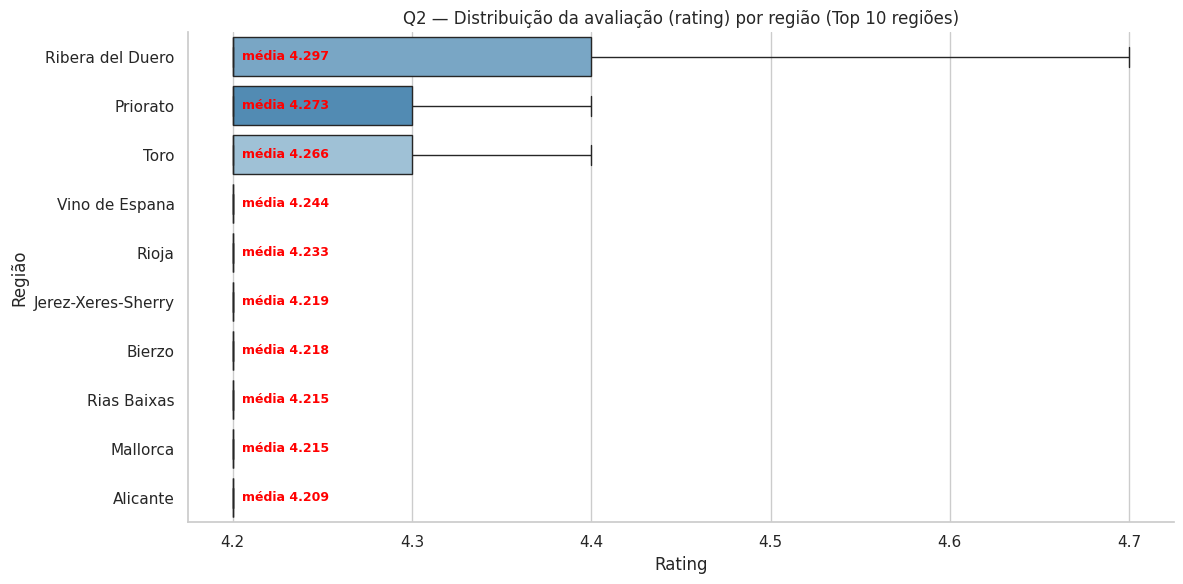

In [114]:
# @title Q2 — Região × Avaliação (responde Q2)

top_regioes_q2 = df['region'].value_counts().nlargest(10).index
df_q2 = df[df['region'].isin(top_regioes_q2)]

ordem_q2 = (df_q2.groupby('region')['rating'].mean()
            .sort_values(ascending=False).index)

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df_q2, x='rating', y='region', order=ordem_q2,
                 palette="Blues_d", hue='region', legend=False, showfliers=False)

medias_q2 = df_q2.groupby('region')['rating'].mean().reindex(ordem_q2)
for i, m in enumerate(medias_q2.values):
    ax.text(4.205, i, f'média {m:.3f}', va='center', fontsize=9,
            color='red', fontweight='bold')

ax.set(title="Q2 — Distribuição da avaliação (rating) por região (Top 10 regiões)",
       xlabel="Rating", ylabel="Região")
sns.despine()
plt.tight_layout()
plt.show()

---

> ✅ **Resposta da Pergunta Q2.**

Como o dataset contém apenas vinhos já bem avaliados (rating mínimo = 4.2), a **mediana é 4.2 em todas as regiões**. A diferença aparece na **média** e na cauda superior:

- **Ribera del Duero** (média 4.297), **Priorato** (4.273) e **Toro** (4.266) lideram e concentram mais vinhos nas notas de excelência (4.6–4.9).
- **Rioja** (4.233), apesar de ser a maior em volume, fica abaixo desse grupo, com a maioria dos rótulos ancorada em 4.2.
- Regiões como **Alicante** (4.209) e **Mallorca** (4.215) ficam na base do ranking.

**Conclusão:** a hipótese de Q2 se sustenta de forma **moderada** — regiões renomadas (Ribera del Duero, Priorato) têm avaliação média ligeiramente superior, mas o efeito é pequeno porque o dataset já é filtrado para vinhos de nota alta. O resultado é coerente com o reforço observado na análise multivariada (era × região).

---


### Q3 — Tipo de vinho × Preço

*Análise bivariada (qualitativa × quantitativa)* — relação entre o tipo de vinho e o `price`.

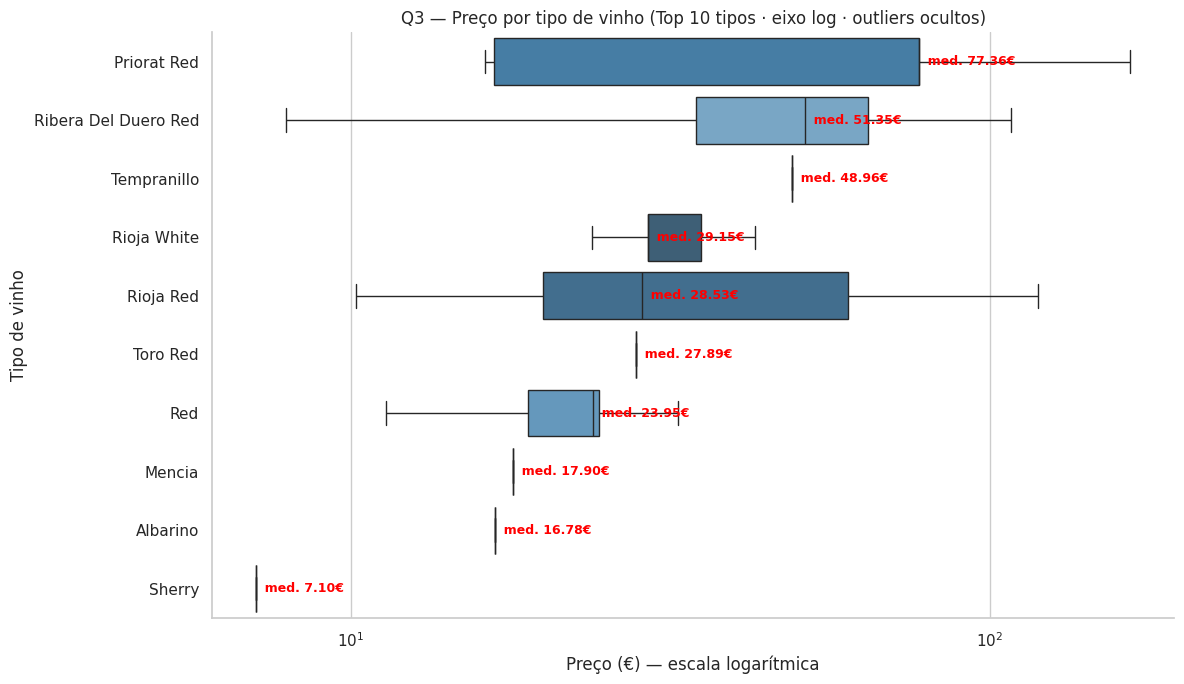

In [115]:
# @title Q3 — Tipo de vinho × Preço (responde Q3)

top_tipos_q3 = df['type'].value_counts().nlargest(10).index
df_q3 = df[df['type'].isin(top_tipos_q3)]

ordem_q3 = (df_q3.groupby('type')['price'].median()
            .sort_values(ascending=False).index)

plt.figure(figsize=(12, 7))
ax = sns.boxplot(data=df_q3, x='price', y='type', order=ordem_q3,
                 palette="Blues_d", hue='type', legend=False, showfliers=False)
ax.set_xscale('log')

medianas_q3 = df_q3.groupby('type')['price'].median().reindex(ordem_q3)
for i, m in enumerate(medianas_q3.values):
    ax.text(m, i, f'  med. {m:.2f}€', va='center', fontsize=9,
            color='red', fontweight='bold')

ax.set(title="Q3 — Preço por tipo de vinho (Top 10 tipos · eixo log · outliers ocultos)",
       xlabel="Preço (€) — escala logarítmica", ylabel="Tipo de vinho")
sns.despine()
plt.tight_layout()
plt.show()

---

> }**Resposta da Pergunta Q3.**

O tipo de vinho **separa fortemente** as faixas de preço (eixo em escala logarítmica para comportar a amplitude):

- Topo: **Priorat Red** (mediana 77,36€) e **Ribera Del Duero Red** (51,35€) — tipos atrelados a regiões prestigiadas.
- Faixa intermediária: **Tempranillo** (48,96€), **Rioja White** (29,15€), **Rioja Red** (28,53€), **Toro Red** (27,89€).
- Base: **Mencia** (17,90€), **Albarino** (16,78€) e **Sherry** (7,10€) — o Priorat Red mediano custa cerca de 10x o Sherry mediano.

**Conclusão:** a hipótese de Q3 **se confirma** — existem tipos sistematicamente mais caros, e essa diferença está fortemente ligada à região/denominação de origem associada ao tipo (Priorat e Ribera del Duero no topo).

---


# Análise Multivariada

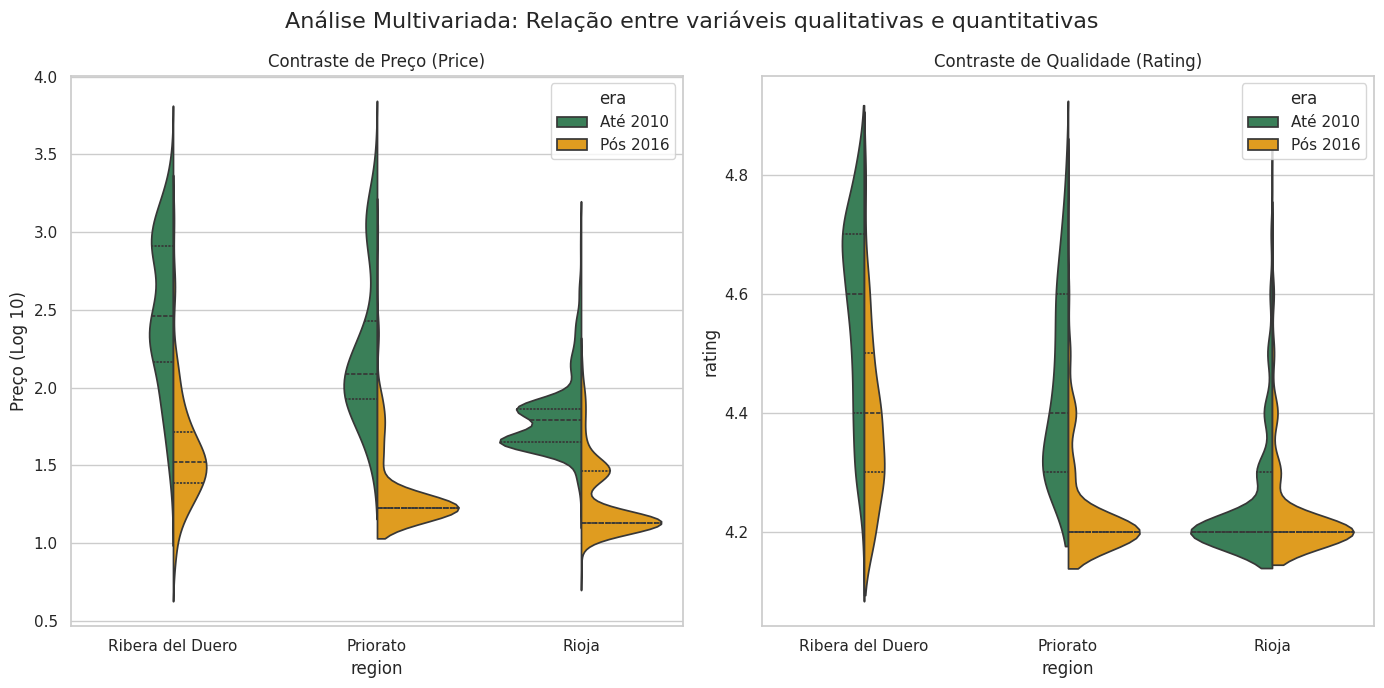

In [116]:
# @title Distribuição Conjunta — Responde Q4 (avaliação, preço e ano) e reforça Q2 (região × avaliação)

# Preparar dados: converter year e criar coluna era
df_temp_for_era = df.copy()
df_temp_for_era['year'] = pd.to_numeric(df_temp_for_era['year'], errors='coerce')
df_temp_for_era = df_temp_for_era.dropna(subset=['year'])
df_temp_for_era['era'] = pd.cut(df_temp_for_era['year'], bins=[1900, 2010, 2016, 2022],
                         labels=['Até 2010', '2011-2016', 'Pós 2016'])
df_final = df_temp_for_era[df_temp_for_era['era'].isin(['Até 2010', 'Pós 2016'])].copy()

df_final['era'] = df_final['era'].cat.remove_unused_categories()

top_regions = df_final['region'].value_counts().nlargest(3).index
df_final = df_final[df_final['region'].isin(top_regions)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

sns.violinplot(
    data=df_final, x='region', y=np.log10(df_final['price']),
    hue='era', split=True, inner="quart", palette={"Até 2010": "seagreen", "Pós 2016": "orange"},
    ax=ax1
)
ax1.set_title('Contraste de Preço (Price)')
ax1.set_ylabel('Preço (Log 10)')

sns.violinplot(
    data=df_final, x='region', y='rating',
    hue='era', split=True, inner="quart", palette={"Até 2010": "seagreen", "Pós 2016": "orange"},
    ax=ax2
)
ax2.set_title('Contraste de Qualidade (Rating)')

plt.suptitle('Análise Multivariada: Relação entre variáveis qualitativas e quantitativas', fontsize=16)
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q4** (avaliação, preço e ano) — e **reforço de Q2** (região × avaliação).

A decisão de filtrar os dados para as três regiões com maior relevância (*Ribera del Duero*, *Priorato* e *Rioja*) e comparar apenas as eras extremas (Até 2010 vs. Pós 2016) foi tomada para garantir melhor interpretabilidade do gráfico. Pois, nas tentativas anteriores com o dataset completo, houve excesso de informação no mesmo espaço, o que dificultava a leitura dos rótulos e a identificação de padrões claros.

Portanto, ao focar nos extremos de maturidade, foi possível isolar com mais clareza o efeito do tempo sobre preço e qualidade. Além disso, a utilização de escala logarítmica no eixo Y ajudou a suavizar o impacto dos vinhos mais caros, permitindo visualizar melhor a distribuição e a densidade dos rótulos nas diferentes faixas de valor.

---

- Em todas as regiões analisadas, os vinhos da era *Até 2010* aparecem em faixas de preço claramente superiores aos da era *Pós 2016*. Em **Ribera del Duero**, por exemplo, a mediana dos vinhos antigos ultrapassa até mesmo o limite superior da maior parte dos vinhos mais novos na mesma região.

- No comparativo de qualidade, apenas os vinhos *Até 2010* conseguem alcançar e manter presença consistente nas notas mais altas (acima de 4.7). Já os vinhos *Pós 2016* apresentam uma base sólida, em torno de 4.2, mas raramente atingem o topo da escala de avaliação.

- **Rioja** mostra um padrão um pouco diferente, enquanto **Ribera del Duero** e **Priorato** apresentam um salto mais evidente de qualidade entre as eras, em **Rioja** as notas médias entre vinhos novos e antigos são mais próximas. Ainda assim, a valorização em preço dos rótulos mais antigos permanece.

- A separação visual consistente entre as eras nos gráficos reforça que tempo de maturação e região são fatores centrais na formação de preço.

> **Conclusão de Q4:** a hipótese se confirma — vinhos com notas altas e de safras mais antigas (Até 2010) ocupam patamares de preço claramente superiores aos das safras recentes. **Conclusão de Q2:** confirma-se o efeito de região (Ribera del Duero e Priorato se valorizam mais), embora em Rioja o contraste de qualidade entre eras seja menor.

---


## Q7 — Corpo × Preço × Região (vinhos com avaliação acima de 4.0)

*Análise multivariada* — cruza três variáveis (`body`, `price`, `region`) restrita aos vinhos com `rating` > 4.0, para verificar se vinhos mais encorpados e bem avaliados são mais caros e se isso varia entre regiões. Usa apenas registros com `body` **originalmente medido** (flag `body_informado`), para não basear a conclusão em valores imputados.

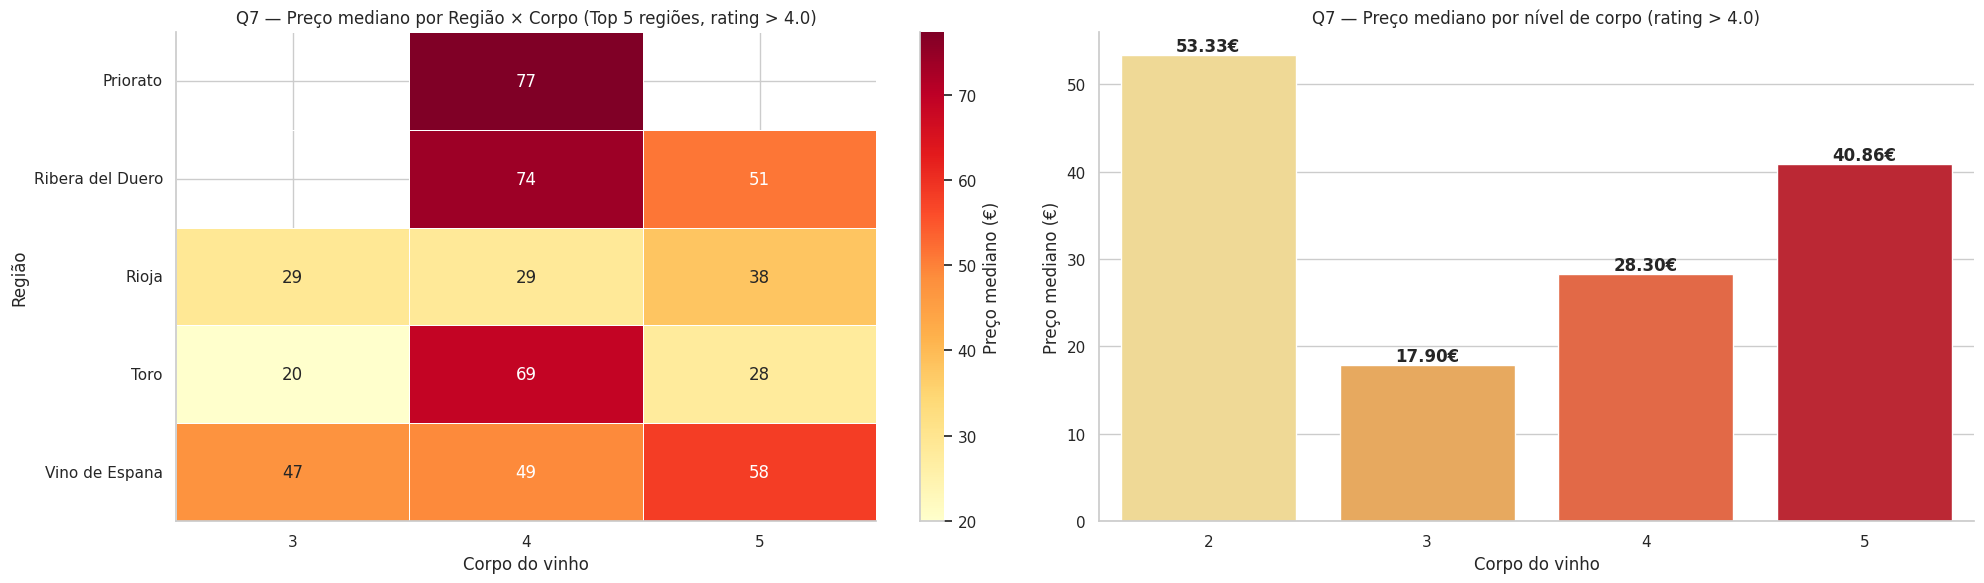

In [117]:
# @title Q7 — Corpo × Preço × Região (rating > 4.0)

# rating > 4.0 abrange todo o dataset (nota mínima = 4.2).
# Usa apenas body ORIGINALMENTE medido (flag), não os imputados.
df_q7 = df[(df['rating'] > 4.0) & (df['body_informado'] == 1)].copy()

top_regioes_q7 = df_q7['region'].value_counts().nlargest(5).index
df_q7_top = df_q7[df_q7['region'].isin(top_regioes_q7)]

pivot_q7 = df_q7_top.pivot_table(index='region', columns='body',
                                 values='price', aggfunc='median')

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

sns.heatmap(pivot_q7, annot=True, fmt=".0f", cmap="YlOrRd",
            linewidths=.5, ax=axes[0], cbar_kws={'label': 'Preço mediano (€)'})
axes[0].set(title="Q7 — Preço mediano por Região × Corpo (Top 5 regiões, rating > 4.0)",
            xlabel="Corpo do vinho", ylabel="Região")

med_body = df_q7.groupby('body')['price'].median()
sns.barplot(x=med_body.index.astype(str), y=med_body.values, ax=axes[1],
            palette="YlOrRd", hue=med_body.index.astype(str), legend=False)
for i, v in enumerate(med_body.values):
    axes[1].text(i, v, f'{v:.2f}€', ha='center', va='bottom', fontweight='bold')
axes[1].set(title="Q7 — Preço mediano por nível de corpo (rating > 4.0)",
            xlabel="Corpo do vinho", ylabel="Preço mediano (€)")

sns.despine()
plt.tight_layout()
plt.show()

---

> **Resposta da Pergunta Q7.** Como a nota mínima do dataset é 4.2, o filtro `rating > 4.0` abrange todos os vinhos; foram excluídos apenas os registros sem `body` originalmente medido (os imputados não entram, via flag).

**Efeito do corpo sobre o preço (visão geral):** há uma tendência crescente clara — preço mediano de **17,90€** (corpo 3) → **28,30€** (corpo 4) → **40,86€** (corpo 5). Vinhos mais encorpados são, de fato, mais caros.

**Efeito da região:** o patamar de preço difere fortemente entre regiões mesmo controlando o corpo. **Priorato** (corpo 4 ≈ 77€) e **Ribera del Duero** (corpo 4 ≈ 74€) operam em níveis bem superiores a **Rioja** (≈ 28–38€) e **Toro**. Nota-se ainda que cada região tende a se especializar em um nível de corpo (ex.: Priorato concentra-se no corpo 4; Ribera del Duero no corpo 5), por isso o mapa de calor apresenta células vazias.

**Conclusão:** a hipótese de Q7 **se confirma** — vinhos com corpo mais intenso e bem avaliados são, em geral, mais caros, e esse patamar de preço é amplificado pelas regiões mais prestigiadas (Priorato e Ribera del Duero).

---


## Mapa de Calor e Dispersão

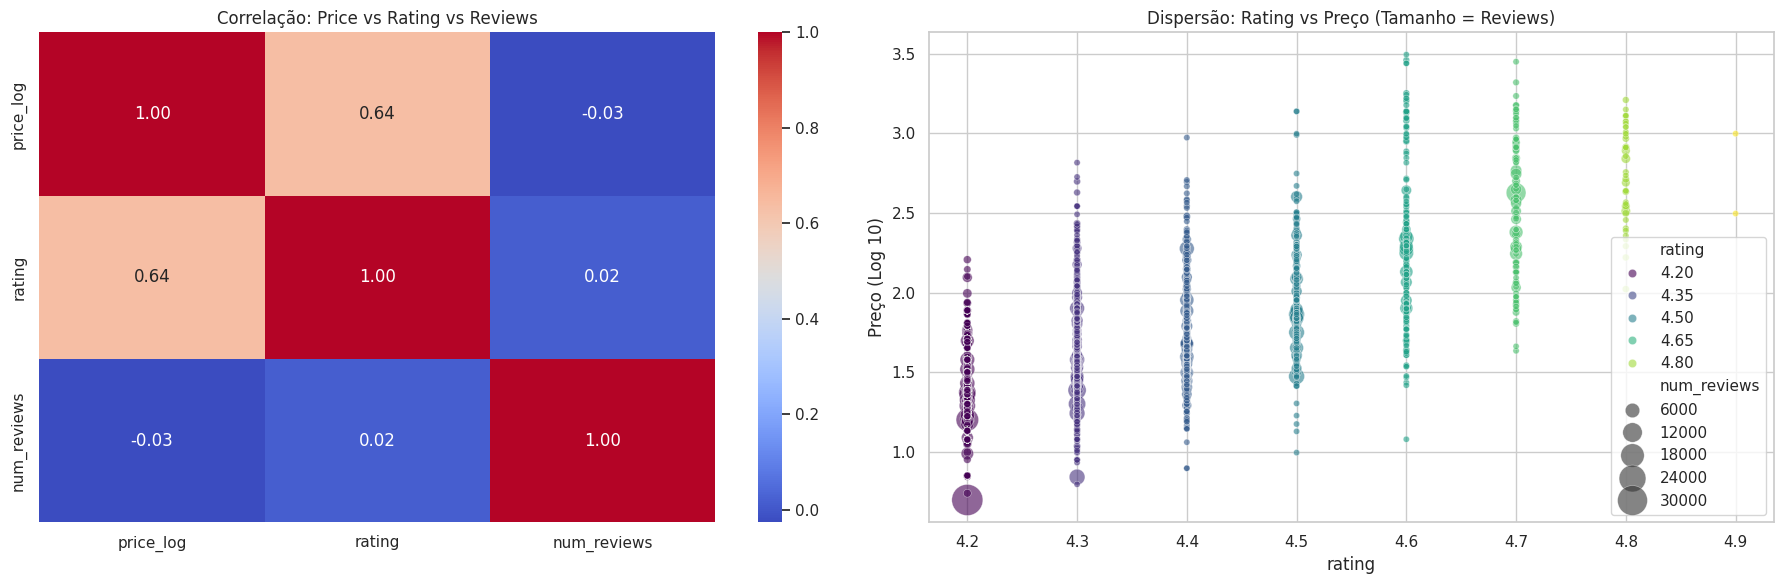

In [118]:
# @title Mapa de Calor e Dispersão — Responde Q1 (avaliação × preço)

df_quant = df.copy()
df_quant['price_log'] = np.log10(df_quant['price'])

corr = df_quant[['price_log', 'rating', 'num_reviews']].corr()

fig, axes = plt.subplots(figsize=(18, 6), ncols=2)

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[0])
axes[0].set_title("Correlação: Price vs Rating vs Reviews")

sns.scatterplot(
    data=df_quant,
    x='rating',
    y='price_log',
    size='num_reviews',
    hue='rating',
    palette='viridis',
    sizes=(20, 500),
    alpha=0.6,
    ax=axes[1]
)
axes[1].set_title("Dispersão: Rating vs Preço (Tamanho = Reviews)")
axes[1].set_ylabel("Preço (Log 10)")

plt.tight_layout()
plt.show()

> **Resposta da Pergunta Q1** (avaliação × preço).

O mapa de calor mostra uma correlação positiva de 0.64 entre *rating* e *price_log*, o que indica uma relação relativamente forte entre as duas variáveis (mais forte do que a correlação linear simples de 0.545, pois a transformação logarítmica do preço lineariza melhor a relação).

Na prática, isso sugere que a pontuação do vinho explica uma parte relevante do seu valor de mercado. À medida que o *rating* aumenta, o preço tende a acompanhar esse movimento de forma consistente. O tamanho dos pontos (número de reviews) não acompanha esse padrão, reforçando o achado de Q5 de que popularidade não está ligada a preço.

> **Conclusão de Q1:** a hipótese se confirma — quanto maior a avaliação, maior o valor de mercado do vinho.


## Análise dos Resultados

### Síntese geral

Esta EDA investigou 7.500 vinhos espanhóis cobrindo 76 regiões, 21 tipos e mais de sete décadas de safras. Das oito perguntas formuladas, **seis hipóteses se confirmaram** e **duas não se sustentaram** (Q5 e Q8), o que por si só já é um resultado analítico.

---

### 1. Avaliação e preço: relação não-linear, mas robusta (Q1)

A correlação linear bruta entre `rating` e `price` é 0.545, mas após a transformação logarítmica do preço sobe para **0.637** — o que indica que a relação segue uma lei de potência, não uma progressão linear. Em termos práticos: cada incremento de nota provoca um salto **multiplicativo**, não aditivo, no preço. Isso é consistente com mercados de bens de luxo e experiência, onde a escassez de produtos de altíssima qualidade justifica prêmios exponenciais.

O dado mais revelador é a compressão das notas (mínimo 4.2, máximo 4.9): todo o dataset já representa o topo da pirâmide de qualidade percebida. Mesmo dentro desse universo filtrado, a diferença de preço entre um vinho 4.2 e um 4.9 pode superar 100×.

---

### 2. Estratificação regional: a denominação de origem como ativo (Q2, Q3, Q4)

Três perguntas independentes convergem para a mesma conclusão: **a origem geográfica é o principal ativo de posicionamento de preço** no vinho espanhol.

- **Q2** mostra que Ribera del Duero e Priorato lideram em avaliação média, com vantagem consistente sobre Rioja — apesar de Rioja ter volume 3× maior.
- **Q3** evidencia que o tipo de vinho (que carrega a região no nome) separa as faixas de preço mais do que qualquer outra variável individual: amplitude de ~10× entre o tipo mais caro (Priorat Red) e o mais barato (Sherry).
- **Q4** acrescenta a dimensão temporal: dentro de cada região, safras mais antigas (pré-2010) sistematicamente alcançam preços e avaliações superiores, e esse efeito é mais pronunciado exatamente nas regiões de prestígio (Ribera del Duero, Priorato).

Esse padrão é teoricamente coerente com a literatura sobre *country-of-origin effect* em bens de experiência: o consumidor usa a denominação como heurística de qualidade, reduzindo incerteza numa categoria em que a qualidade só é verificável após o consumo.

---

### 3. Popularidade desconectada de qualidade e preço (Q5)

A correlação entre número de reviews e preço é de apenas −0.030, e com rating de +0.015 — ambas economicamente insignificantes. Isso desconstrói a hipótese intuitiva de que vinhos mais acessíveis (baratos) seriam mais avaliados por maior alcance de público.

Uma explicação plausível: a plataforma de origem dos dados atrai consumidores especializados que avaliam vinhos independentemente de faixa de preço. O engajamento parece ser dirigido por fatores externos aos dados (campanhas de divulgação de vinícolas, lançamentos, prêmios em competições), não pelo preço nem pela nota.

---

### 4. Corpo como proxy de estilo, não de qualidade (Q7)

O corpo do vinho mostrou correlação de +0.155 com preço e +0.161 com rating — fracas, mas consistentes. A análise multivariada de Q7 revelou que o efeito de corpo sobre preço existe, mas é amplificado (ou dominado) pela região: um vinho de corpo 4 em Priorato custa ≈77€, enquanto em Rioja o mesmo corpo custa ≈28–38€.

Isso sugere que o corpo do vinho funciona mais como uma **característica de estilo regional** do que como um sinal independente de qualidade: regiões quentes e de solos pobres (como Priorato) produzem naturalmente vinhos mais encorpados e mais caros, mas a causalidade vai da região ao corpo — não o contrário.

---

### 5. Acidez: achado contraintuitivo com ressalva metodológica (Q8)

Q8 registrou a única relação **inversa** clara: acidez menor → preço maior. O resultado é estatisticamente observável, mas metodologicamente frágil: 95% dos vinhos têm acidez nível 3, e o grupo de acidez 1 tem apenas 35 registros. Pequenas flutuações nesse grupo mudariam a conclusão.

Uma interpretação cautelosa: os poucos vinhos de baixíssima acidez no dataset podem ser vinhos de estilo específico (Sherry, varietais oxidativos) que coincidem com preços fora do padrão. **Não se pode generalizar** que "acidez baixa causa preço alto" — o dado é insuficiente para uma inferência causal nesse sentido.

---

### 6. Dados ausentes como informação: o padrão MAR

A taxa de ausência de `body`/`acidity` caiu de ~21% (quartil de preço mais baixo) para ~8% (quartil mais caro). Esse padrão MAR (*Missing At Random*, condicionado ao preço) tem implicação direta para análise: a ausência sinaliza que o registro provém de um segmento diferente do mercado (vinhos mais baratos, menos documentados nas plataformas). As flags `body_informado`/`acidity_informado` preservaram esse sinal e foram usadas em Q7 e Q8 para garantir que as conclusões se baseiem em dados efetivamente medidos.

---

### Conclusão

O mercado de vinhos espanhóis de alta avaliação é estruturado por **três eixos de valor interdependentes**: **avaliação** (prêmio exponencial de preço), **origem geográfica/tipo** (estratificação primária por DO) e **safra/maturidade** (valorização temporal). Popularidade de plataforma, corpo e acidez têm efeitos secundários e mais específicos. Para uma análise preditiva futura, as variáveis de maior poder explicativo seriam: `rating`, `type`/`region` (como categórica), `year` (agrupado em era) e `body` — nessa ordem de relevância.


# Resultados

## Tabela de Perguntas, Hipóteses e Resultados

| # | Pergunta | Hipótese | Resultado | Achado-chave | Categoria |
|---|---|---|---|---|---|
| **Q1** | Há relação entre avaliação e preço? | Maior avaliação → maior preço | **Confirmada** | r(rating, price_log) = **0.637**; vinhos 4.9 chegam a 3.119€ | Bivariada / Multivariada |
| **Q2** | A região afeta a avaliação? | Regiões renomadas têm qualidade superior | **Confirmada** (parcialmente) | **Ribera del Duero** lidera (média 4.297) vs. Rioja (4.233); diferença moderada, pois todo o dataset já é de nota alta | Bivariada |
| **Q3** | O tipo de vinho interfere no valor? | Existem tipos sistematicamente mais caros | **Confirmada** | **Priorat Red** (mediana 77€) vs. **Sherry** (7€): diferença de ~10× entre tipos | Bivariada |
| **Q4** | Qual a relação entre avaliação, preço e ano? | Vinhos antigos e bem avaliados são mais caros | **Confirmada** | Safras "Até 2010" dominam notas ≥ 4.7 e faixas de preço mais altas em todas as regiões analisadas | Multivariada |
| **Q5** | Existe relação entre preço e nº de reviews? | Vinhos mais baratos têm mais reviews | **Não confirmada** | r(price, num_reviews) = **−0.030** ≈ 0; popularidade e preço são independentes neste dataset | Bivariada |
| **Q6** | Como varia a diversidade de tipos entre as 10 principais regiões? | Algumas regiões são mais diversas por clima, solo e tradição | **Confirmada** | **Vino de Espana** (6 tipos) e **Rioja** (5) lideram; regiões com DO forte concentram-se em 1–2 tipos | Bivariada (qual × qual) |
| **Q7** | Como o corpo influencia o preço em vinhos com rating > 4.0? | Vinhos mais encorpados e bem avaliados são mais caros | **Confirmada** | Corpo 3 → 17,90€ / corpo 4 → 28,30€ / corpo 5 → **40,86€**; efeito amplificado pela região (Priorato corpo 4 ≈ 77€) | Multivariada |
| **Q8** | A acidez interfere no preço? | Acidez moderada (nível 2) associada a preços mais altos | **Não confirmada** | Relação **inversa**: acidez 1 (baixa) → mediana 114,50€ vs. acidez 3 (alta) → 28,53€; mas n=35 para acidez 1 — resultado com ressalva | Bivariada |
